In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "processed_timeseries_table_timeseries_table " + "(1)" + ".csv"

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "lsobieski/processed-thermostat-data",
  file_path,
)

In [3]:
df.head()

,Timestamp,Temperature,Setpoint,FanState,OutputState,RunningMode_cool,RunningMode_heat,RunningMode_off,CumulativeRuntime,CumulativeCost,Outdoor_Temperature,outsideMinTemp,outsideMaxTemp,outsideHumidity
0,2025-02-05 15:53:08,22.1,23.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,10.692442,10.14,12.80,88.0
1,2025-02-05 15:53:10,22.1,23.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,10.692664,10.14,12.80,88.0
2,2025-02-05 16:05:10,22.1,23.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,10.772575,10.14,12.80,88.0
3,2025-02-05 16:39:33,22.1,23.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,10.627622,9.97,12.47,91.0
4,2025-02-05 16:39:34,22.1,23.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,10.627600,9.97,12.47,91.0


In [4]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')

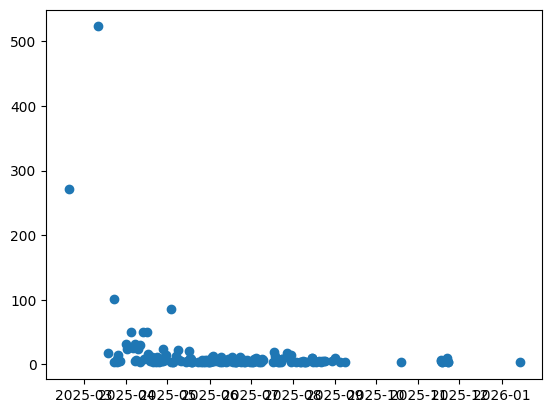

In [5]:
df = df.sort_values("Timestamp")

df["timestamp_diff"] = df["Timestamp"].diff()

df["gap_hours"] = df["timestamp_diff"].dt.total_seconds() / 3600

df["large_gap"] = df["gap_hours"] > 3

gaps = df[df["large_gap"]].copy()


plt.figure()
plt.scatter(gaps['Timestamp'], gaps["gap_hours"])

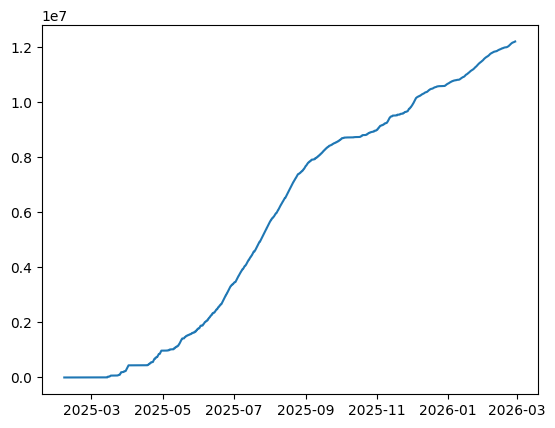

In [6]:
plt.plot(df['Timestamp'], df['CumulativeRuntime'])

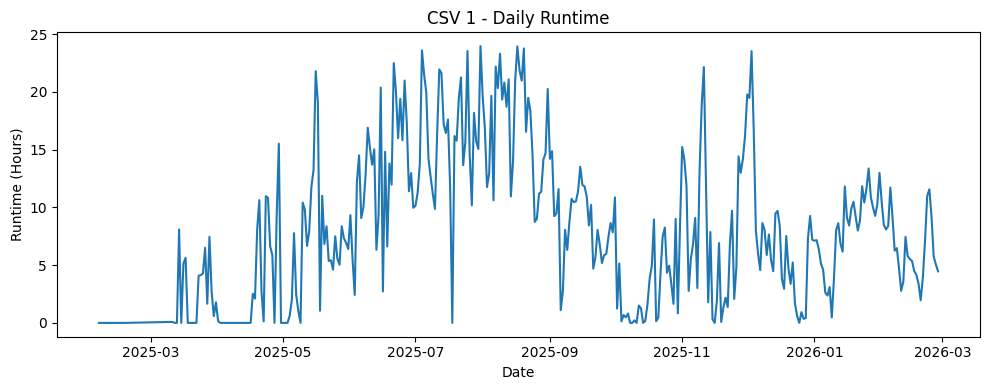

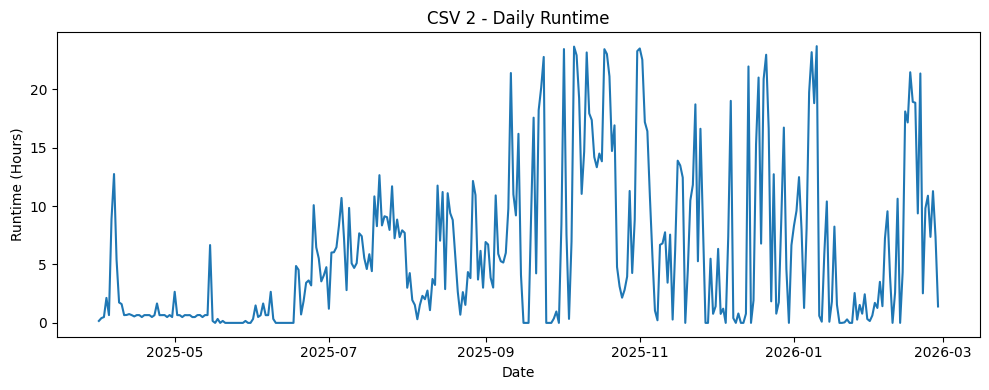

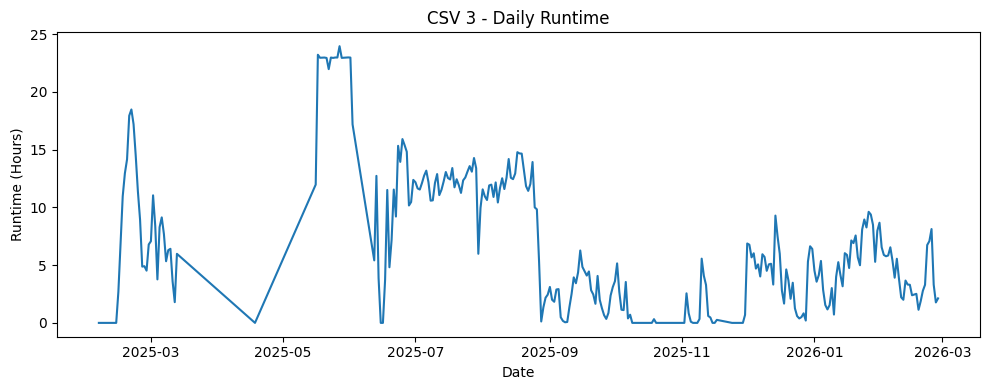

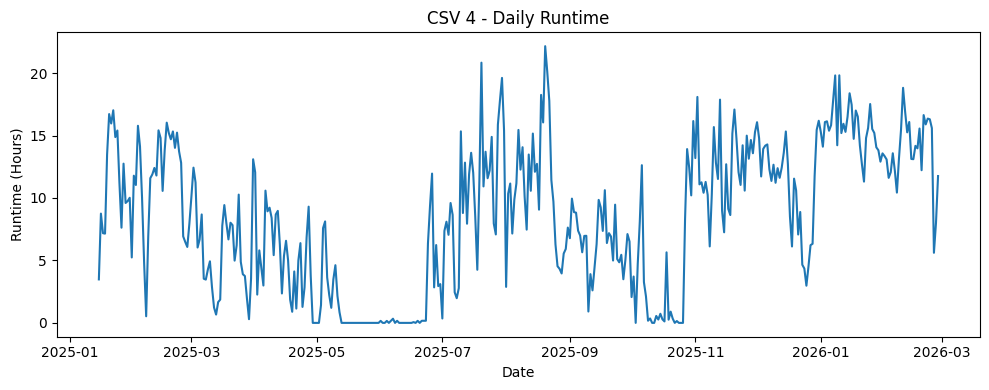

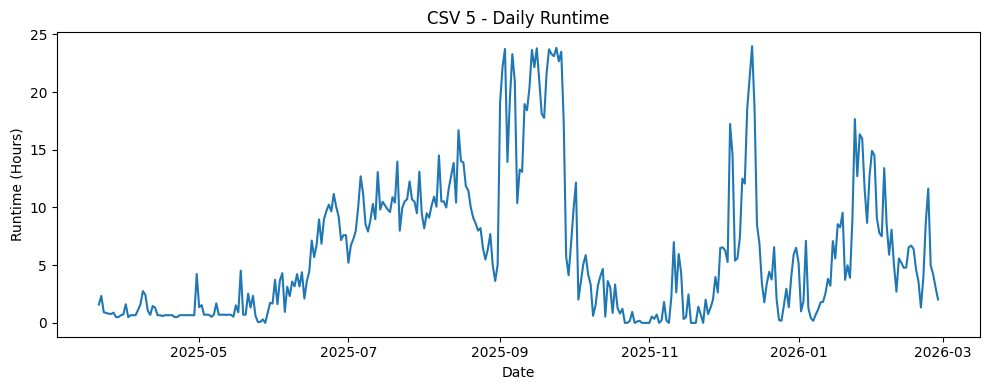

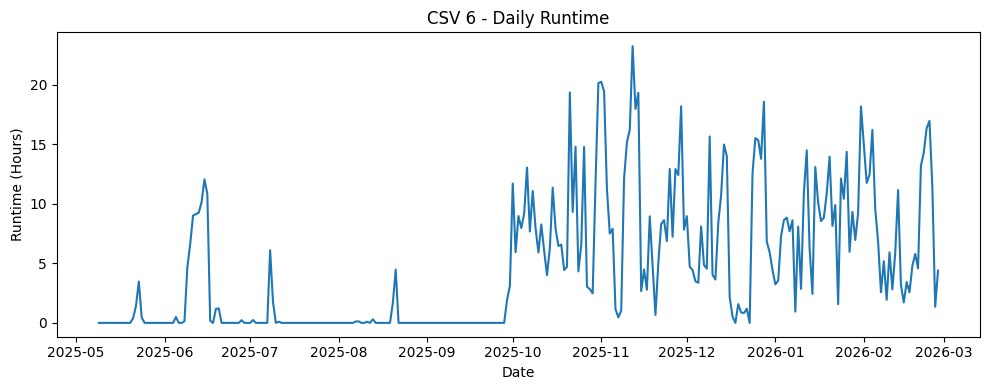

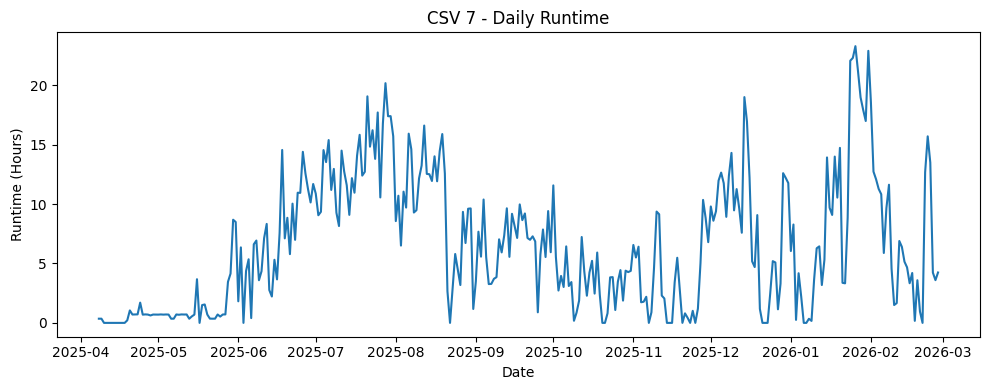

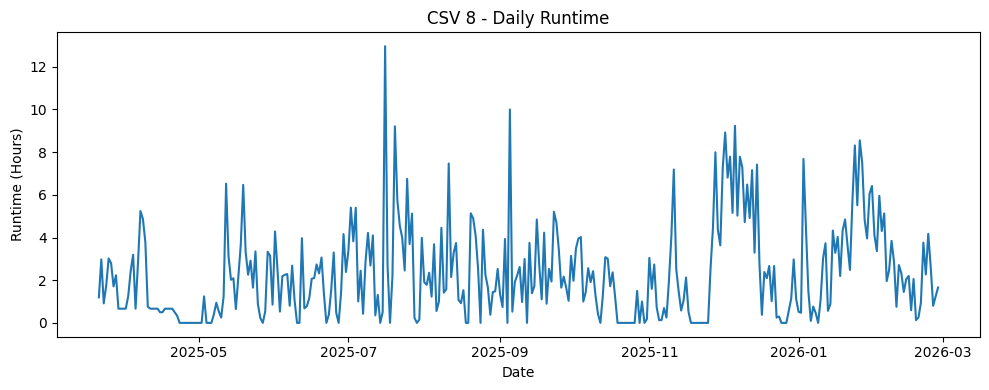

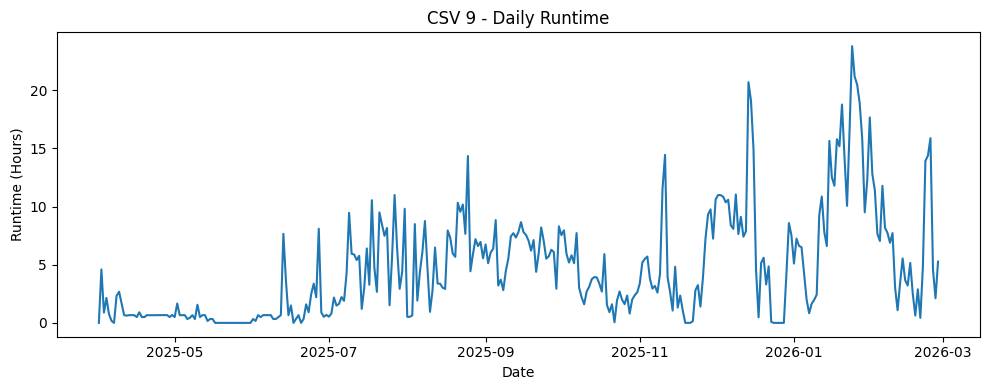

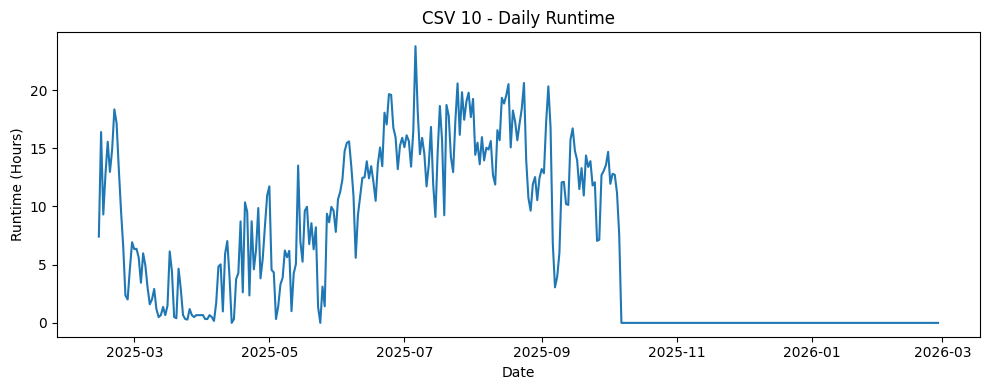

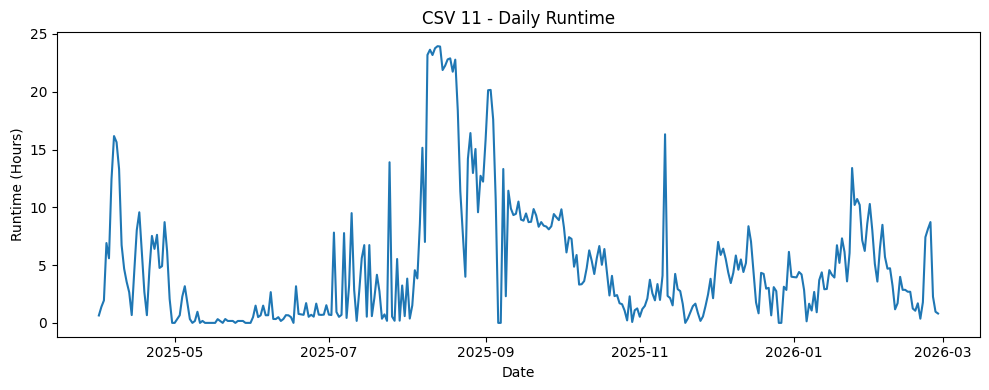

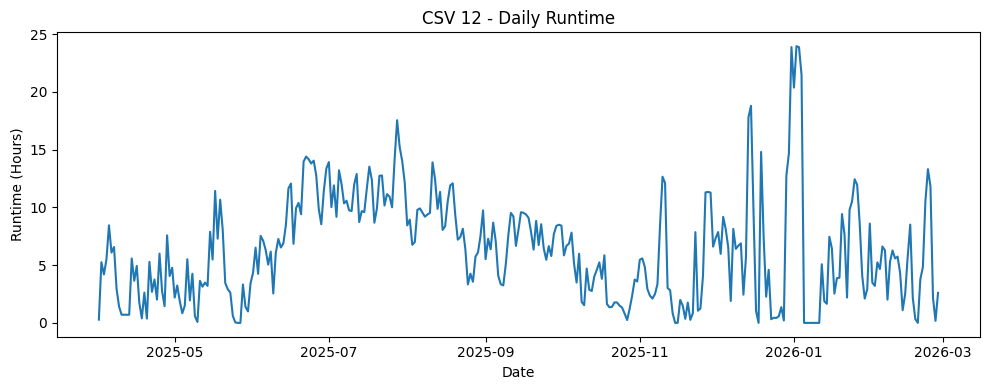

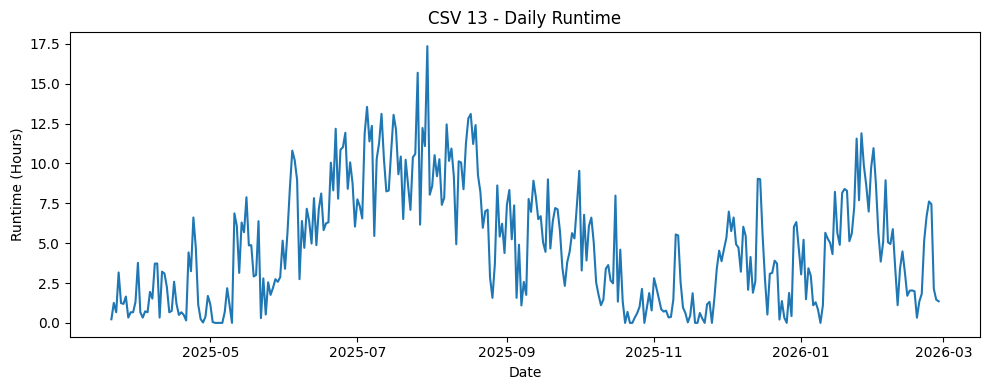

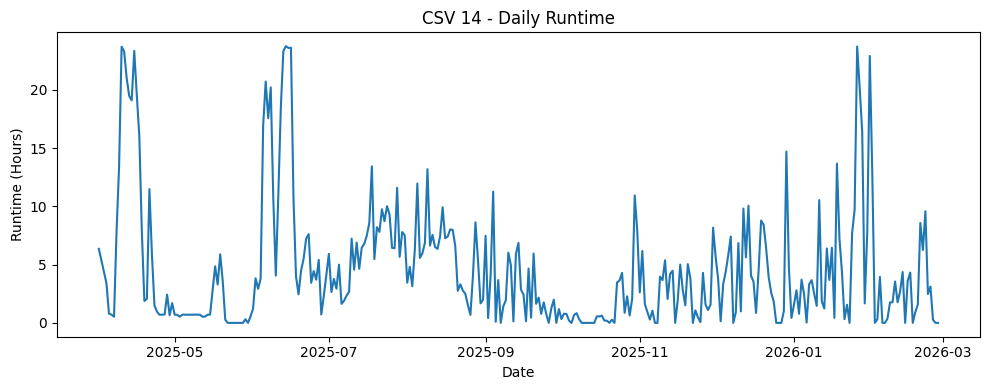

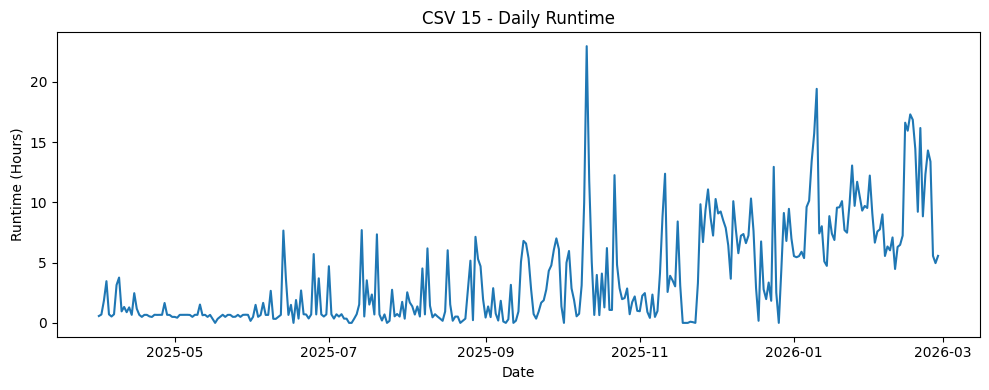

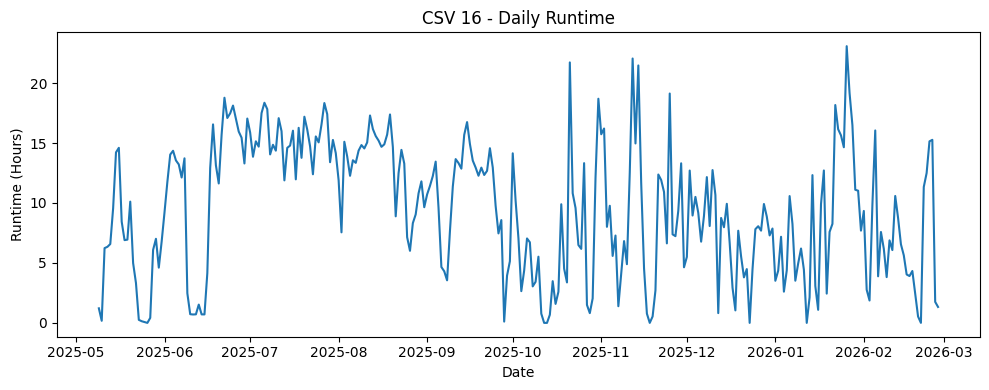

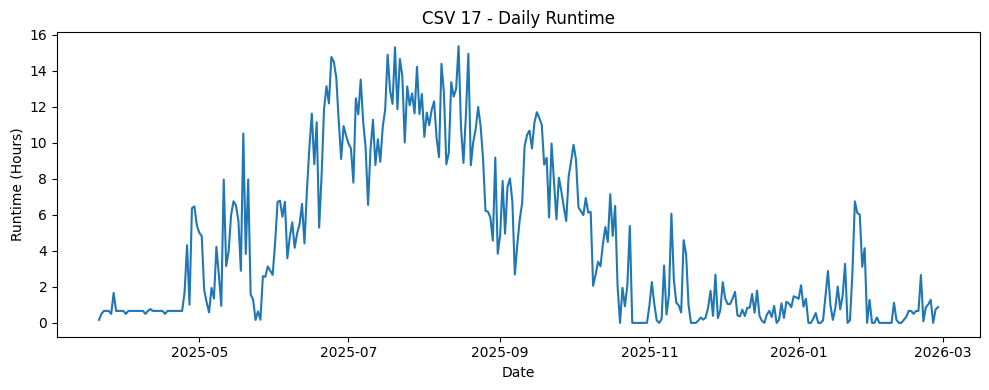

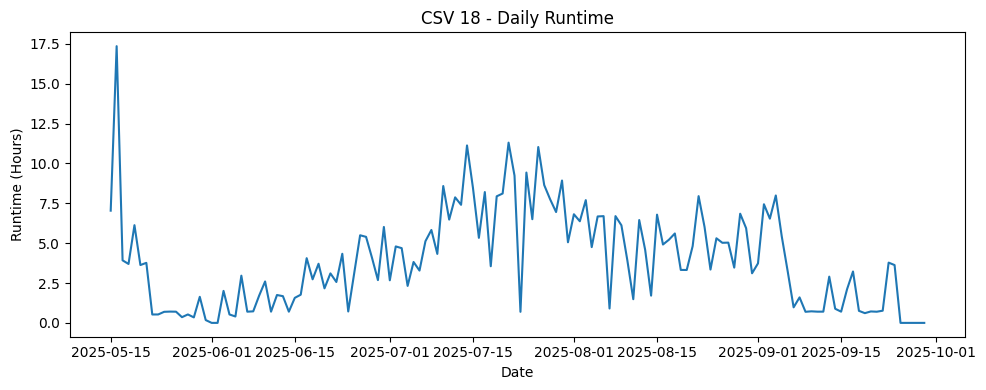

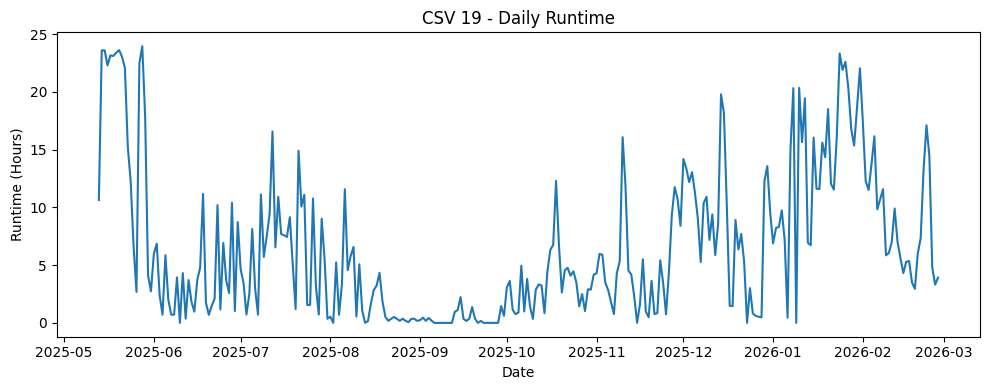

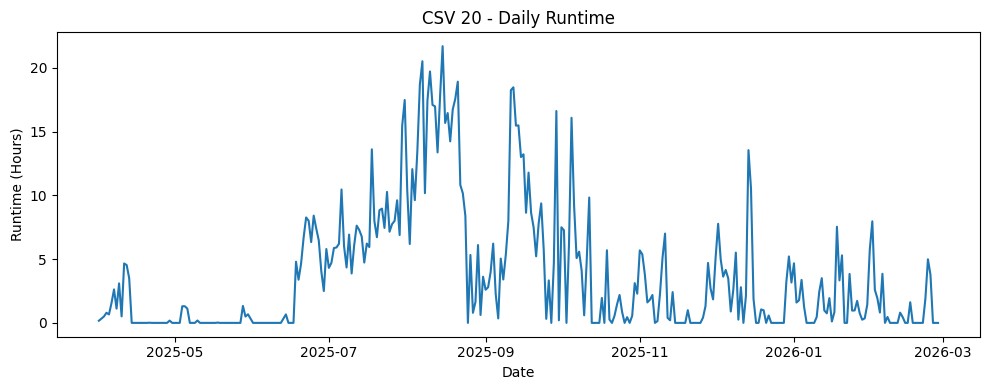

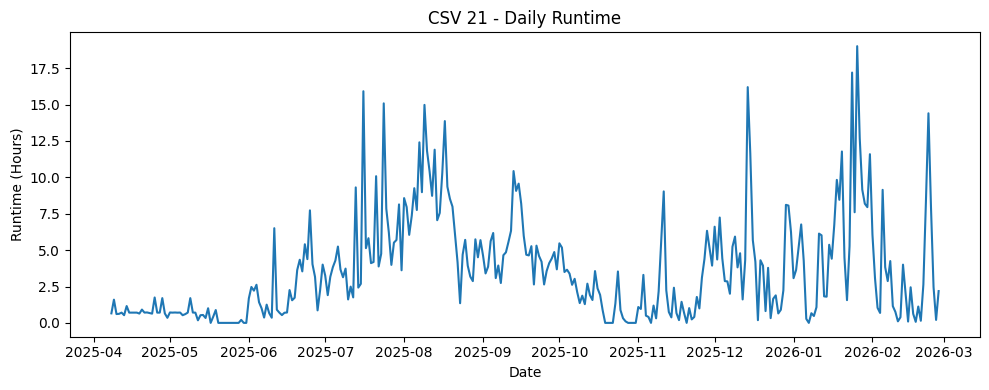

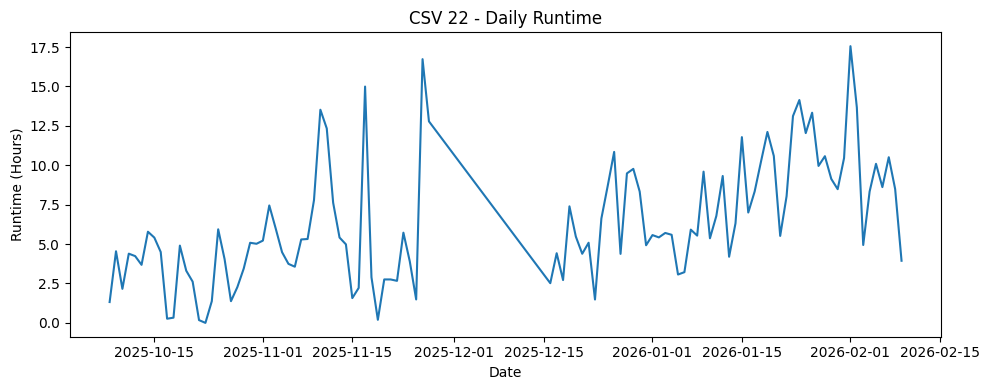

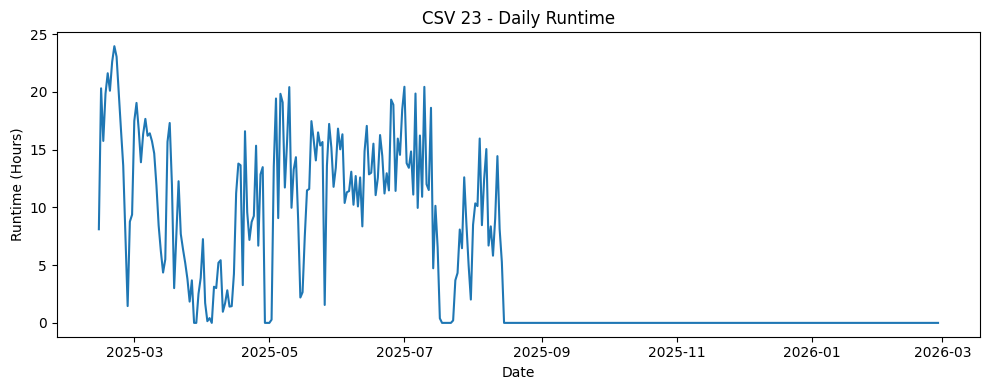

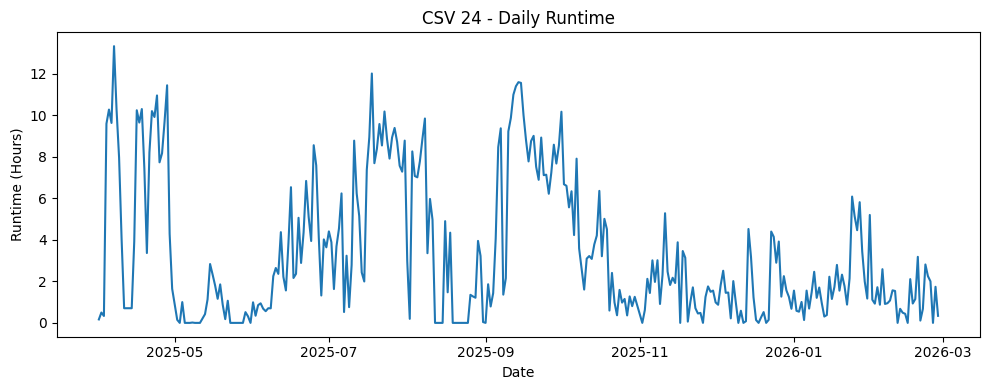

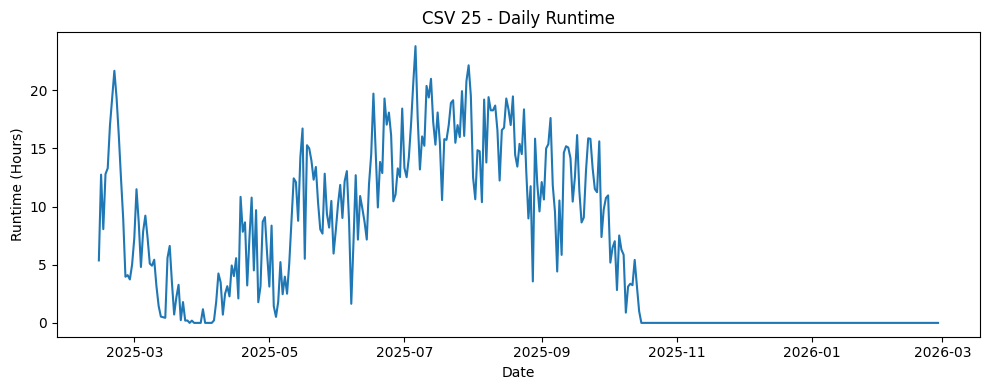

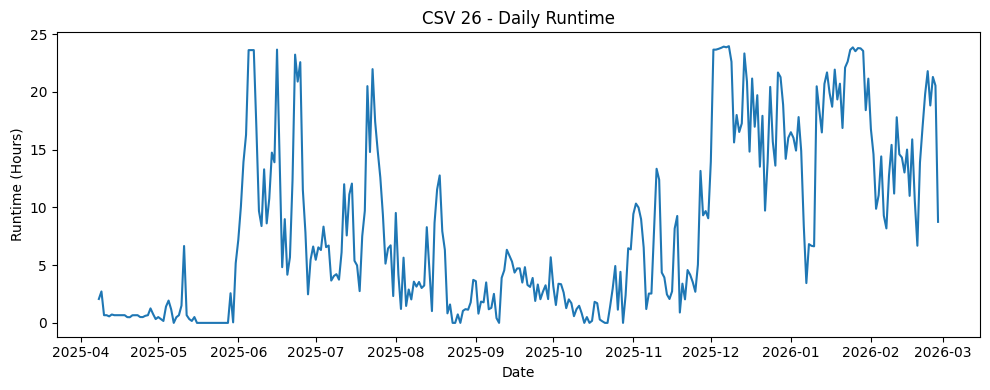

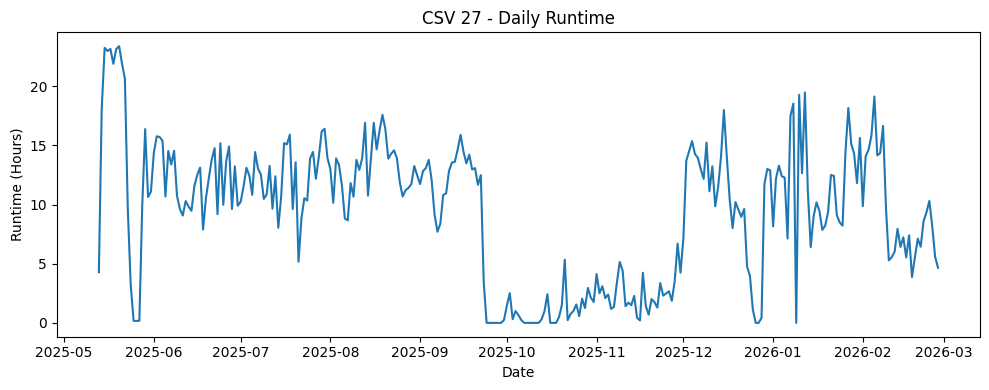

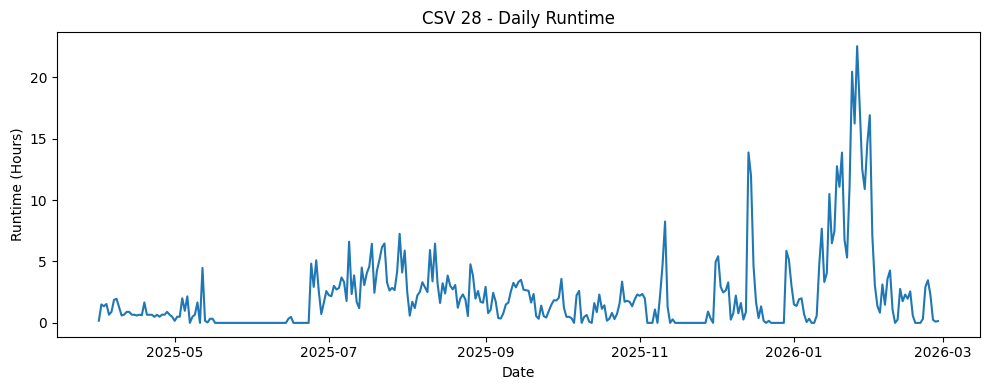

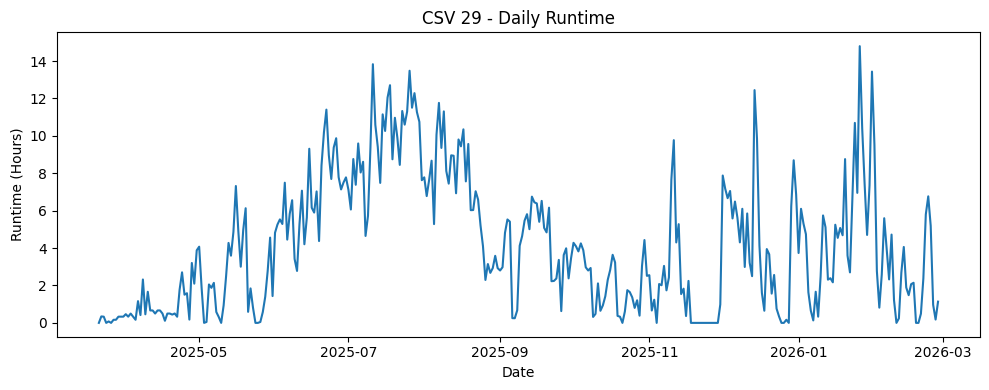

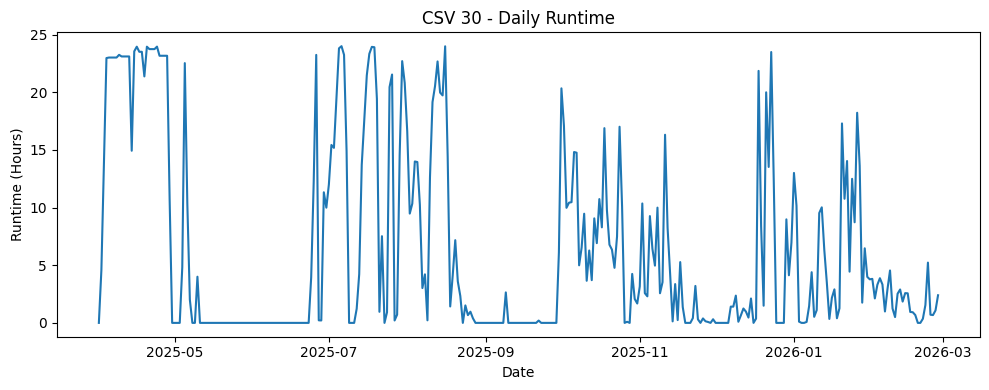

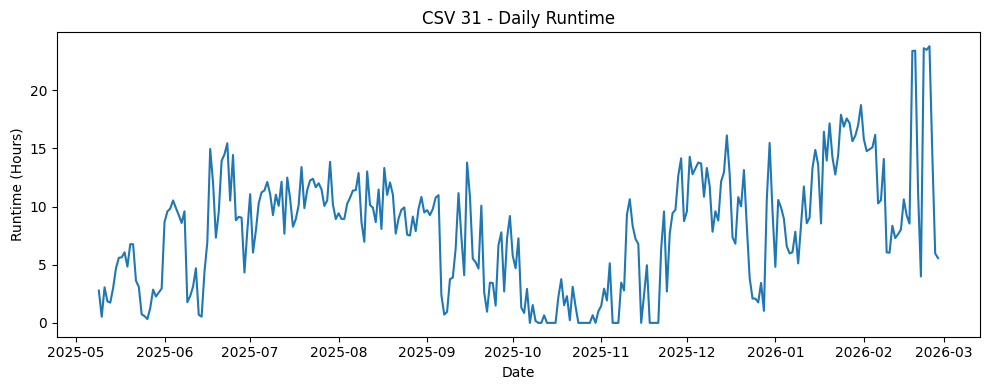

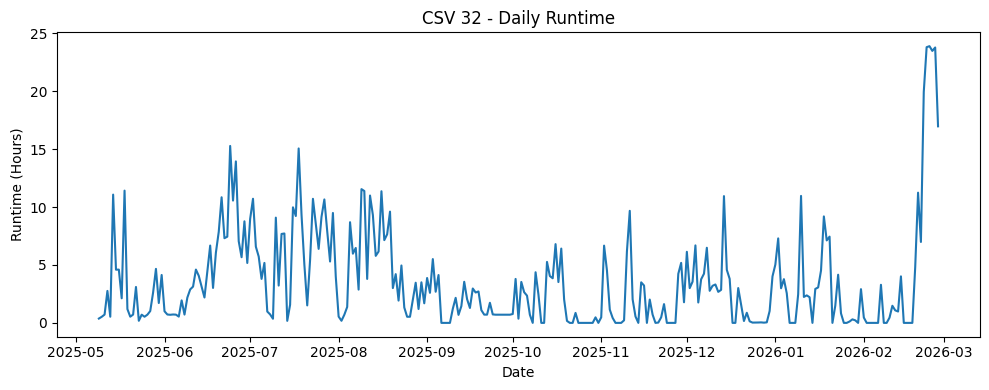

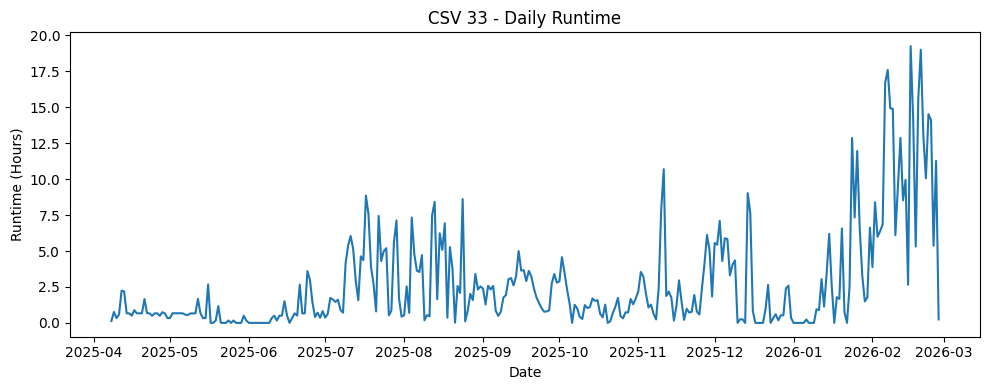

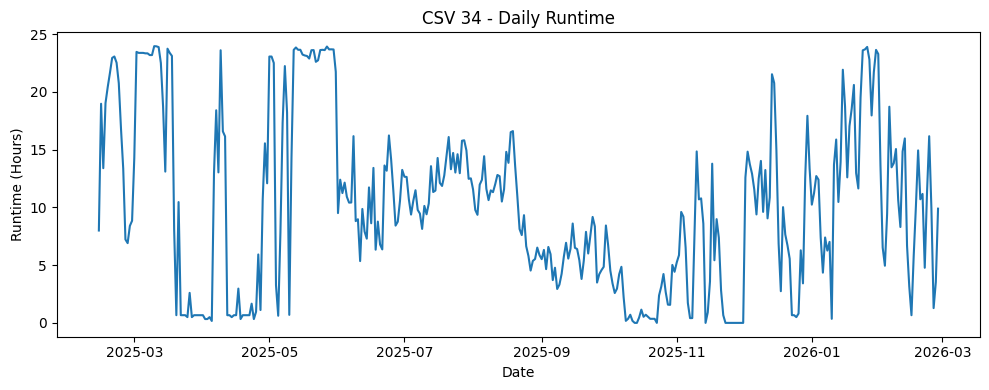

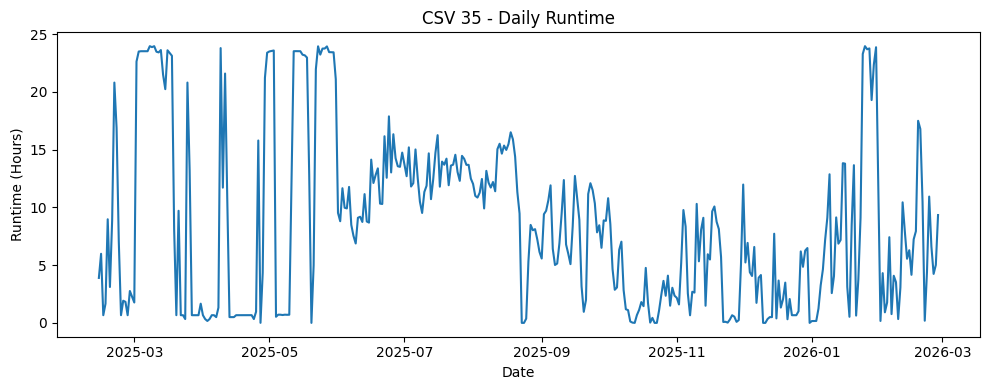

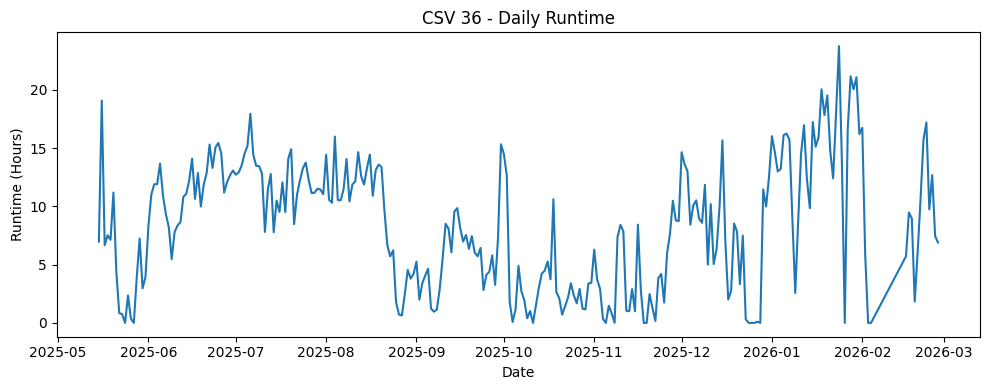

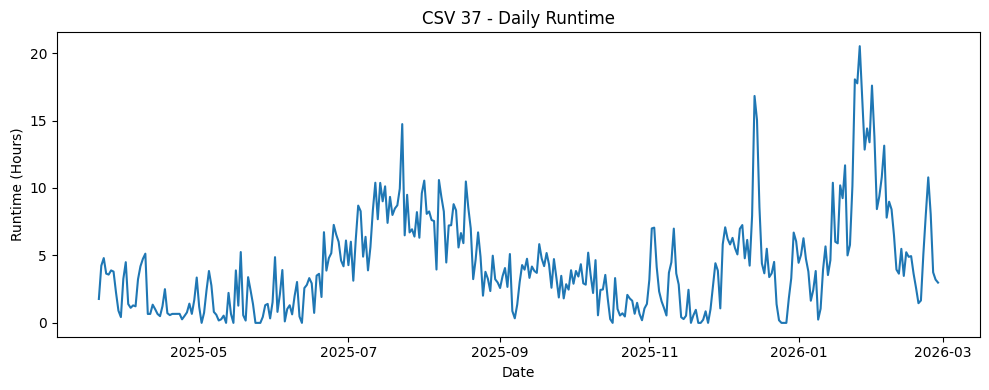

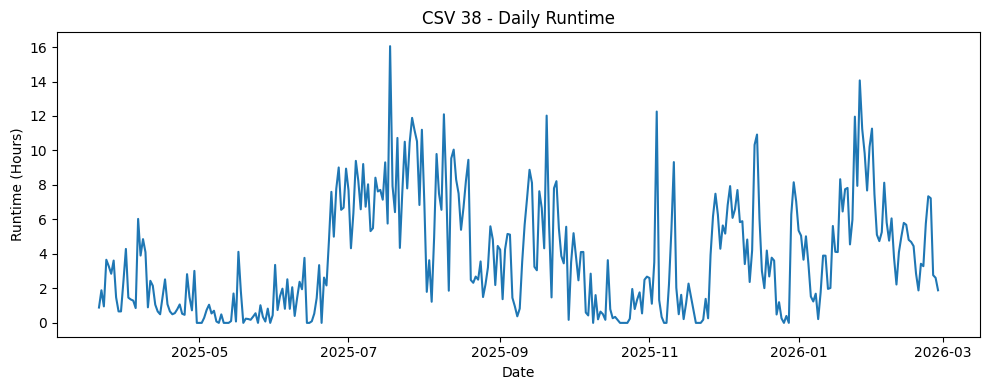

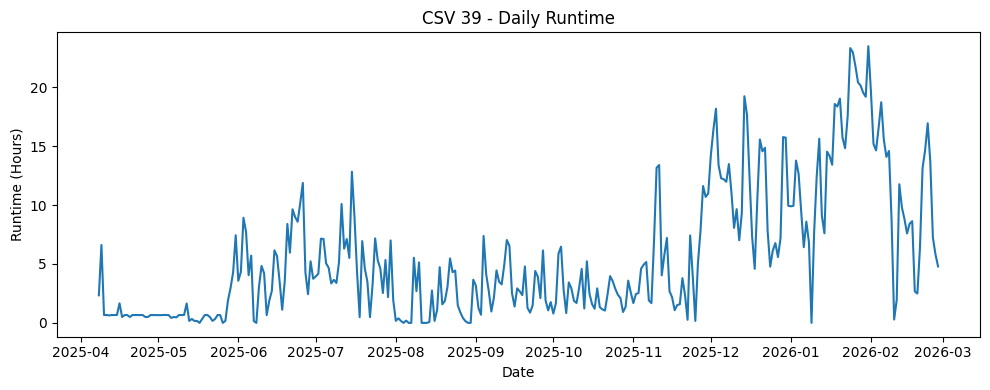

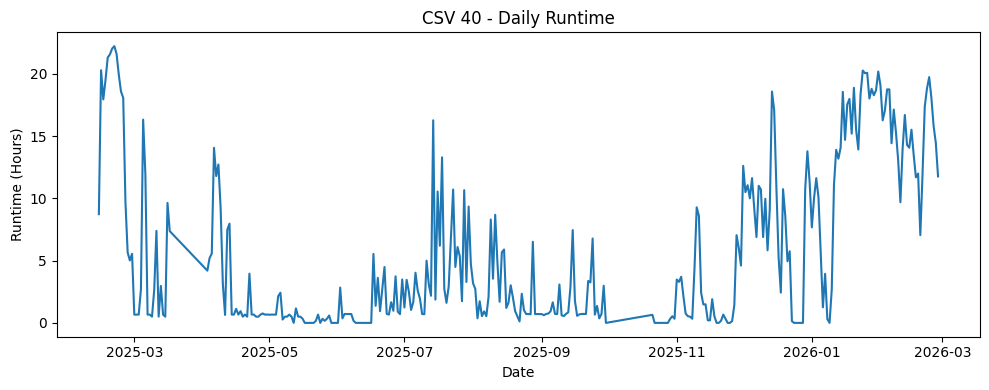

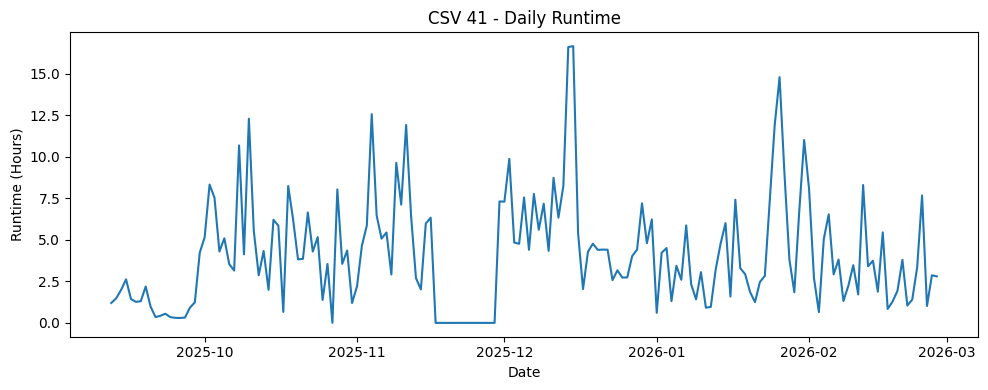

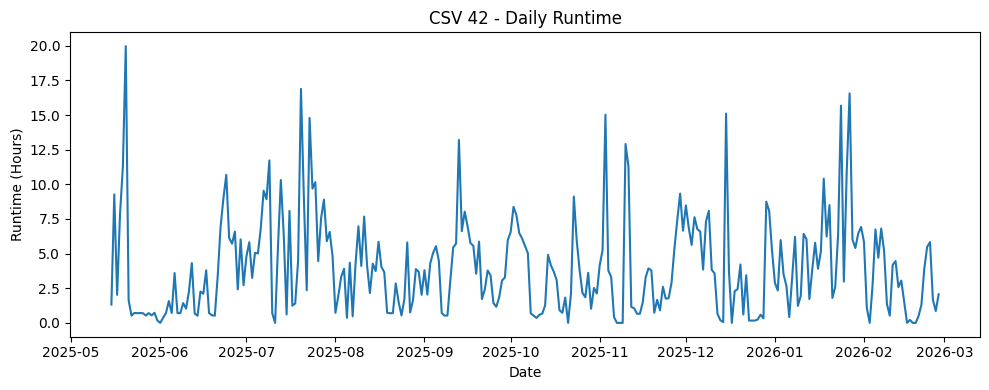

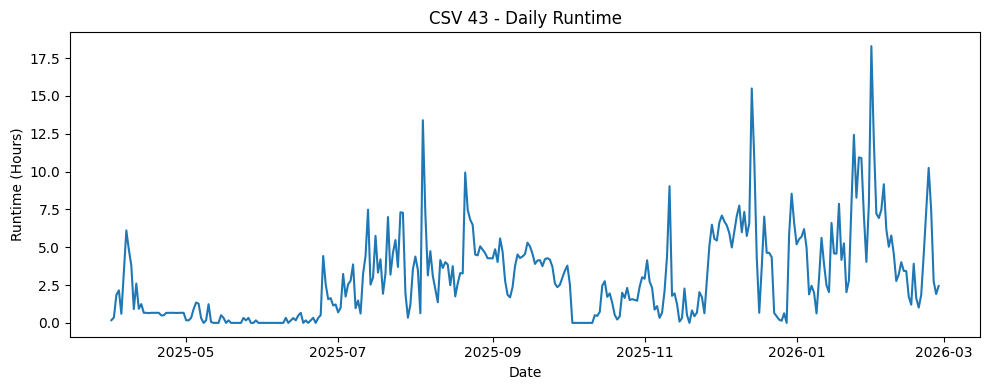

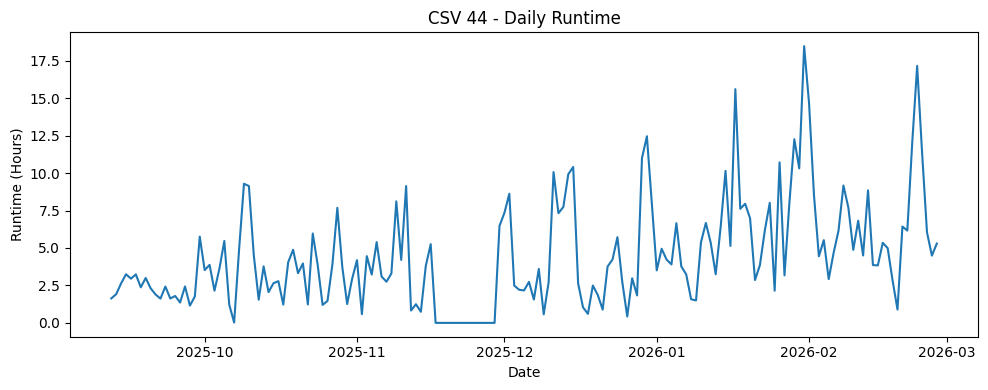

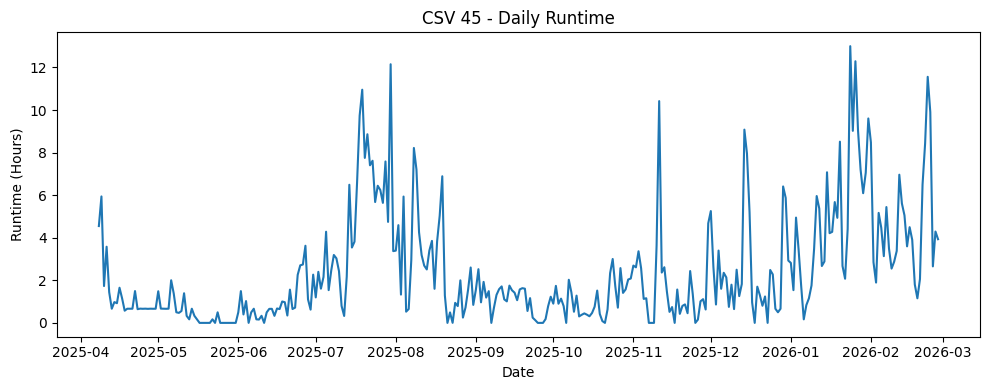

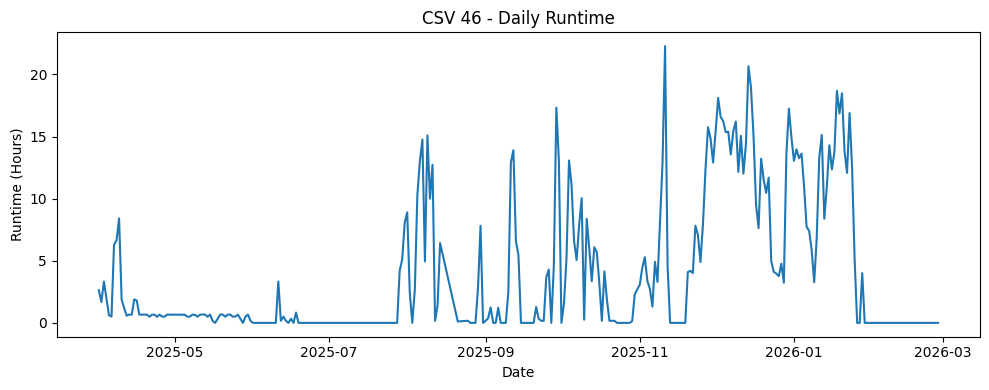

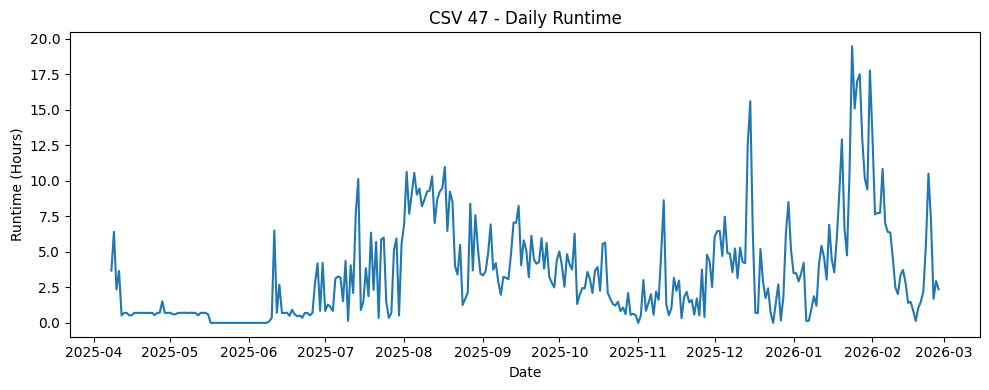

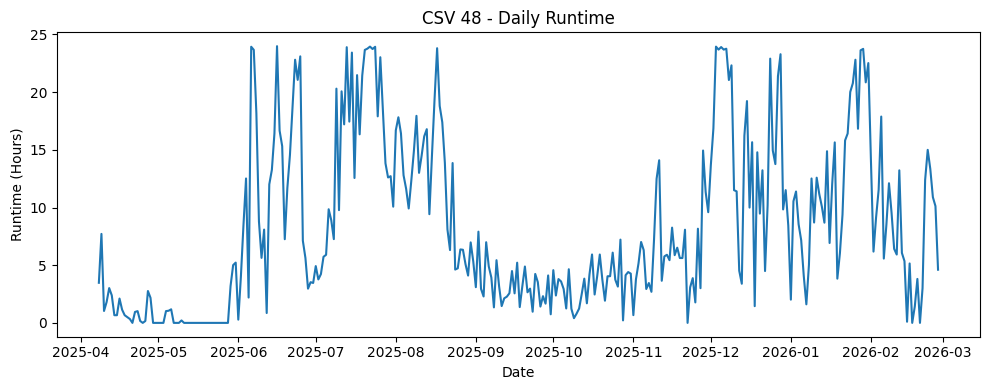

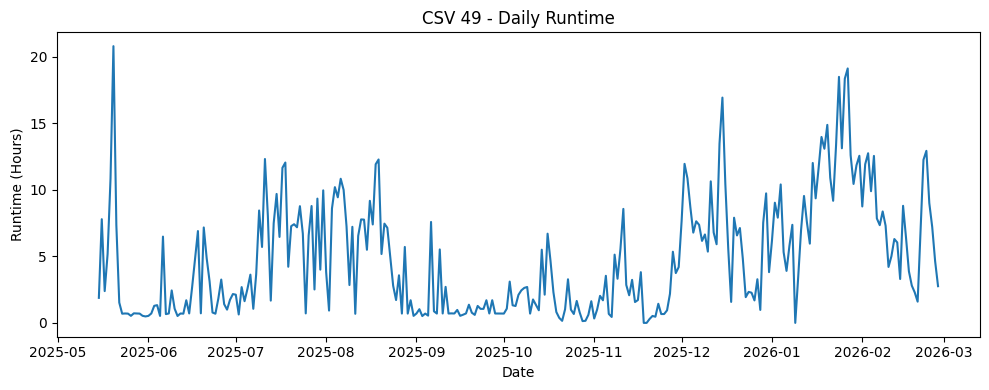

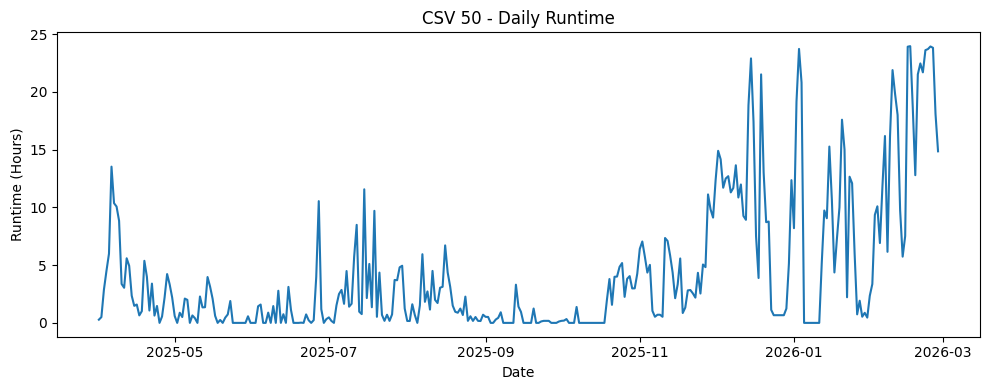

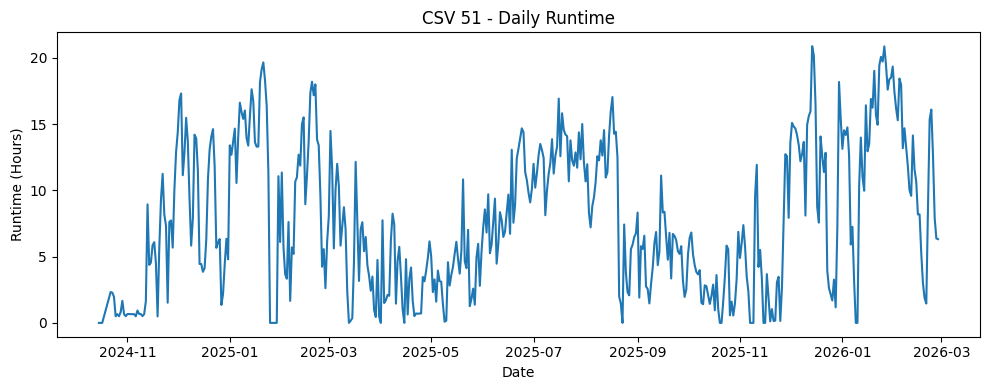

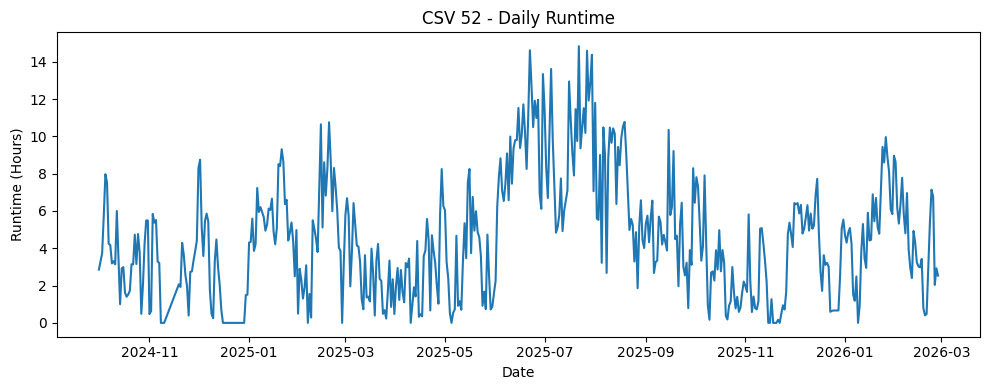

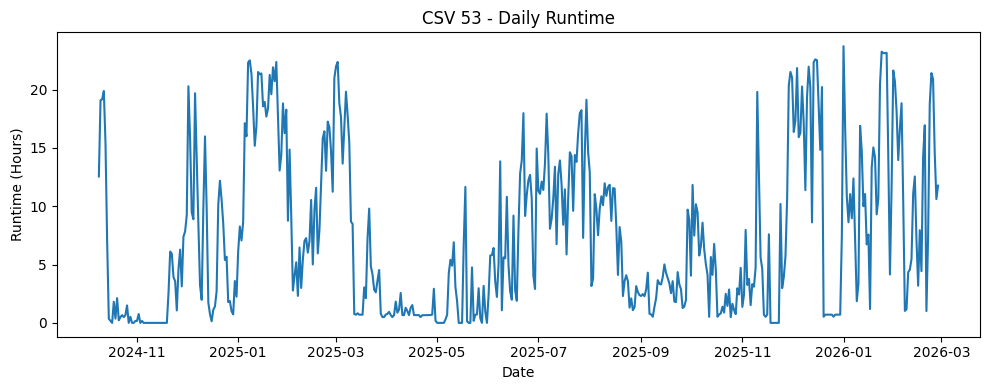

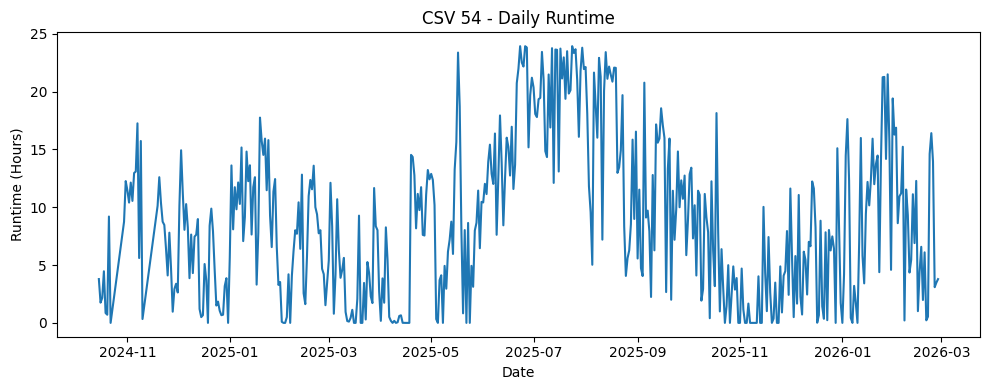

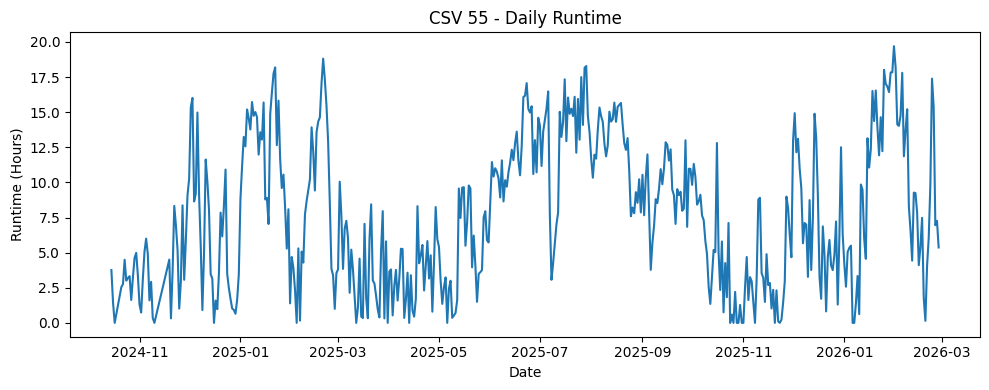

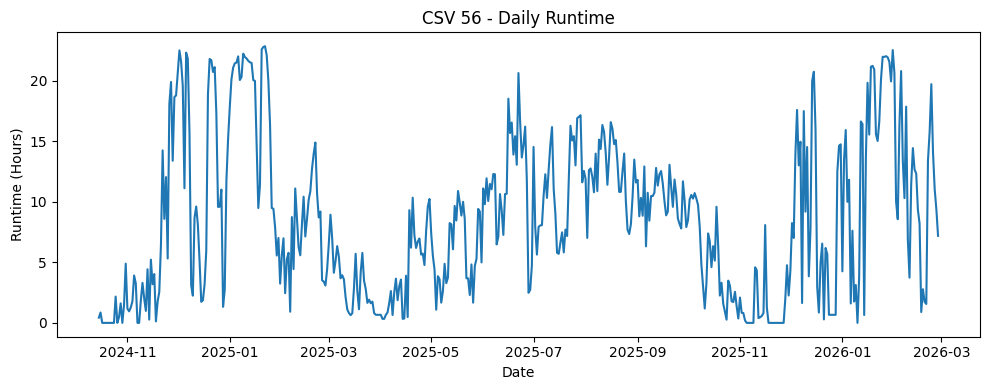

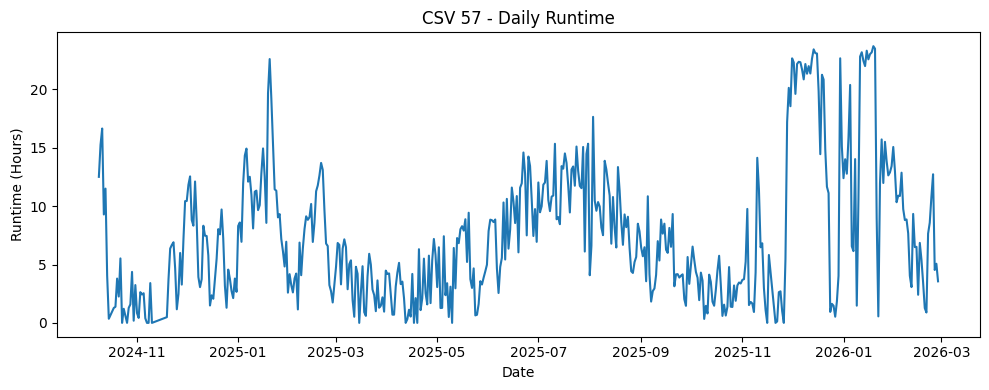

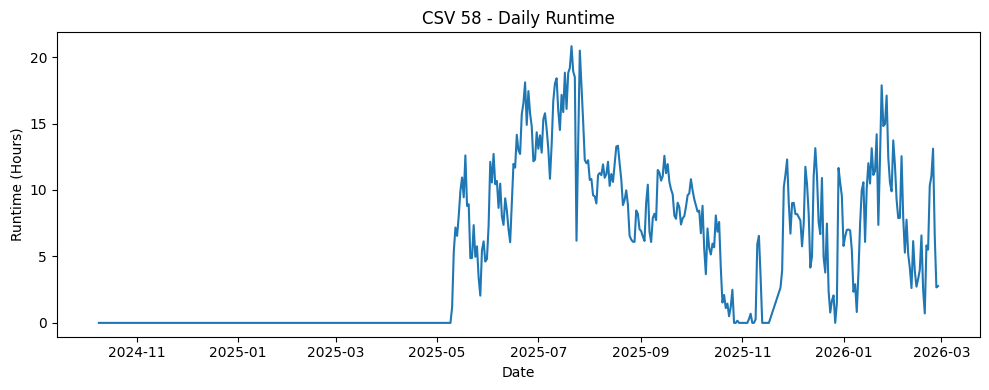

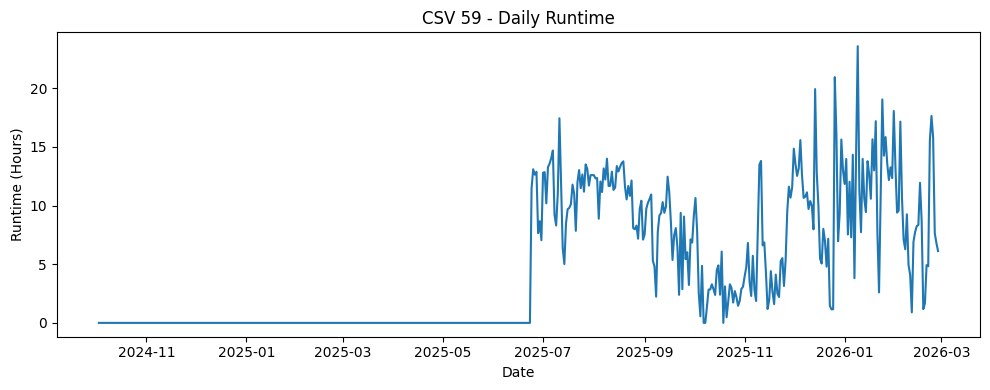

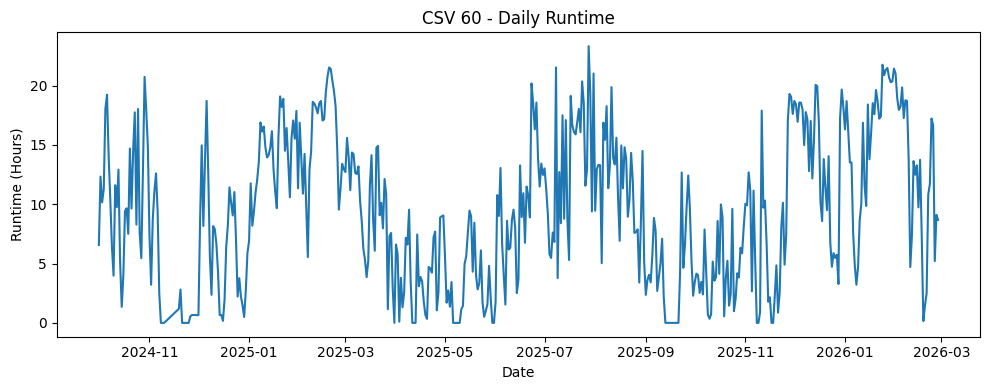

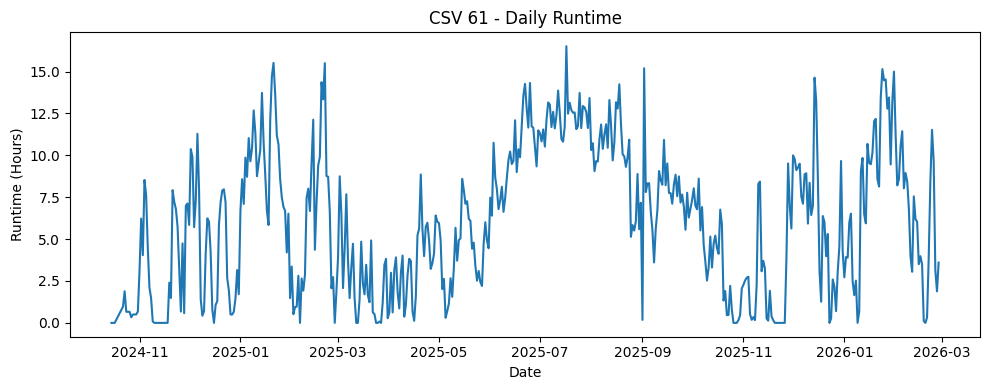

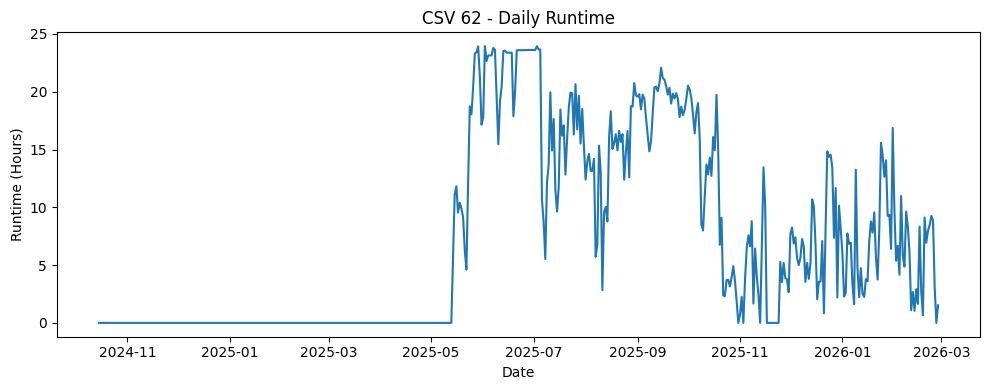

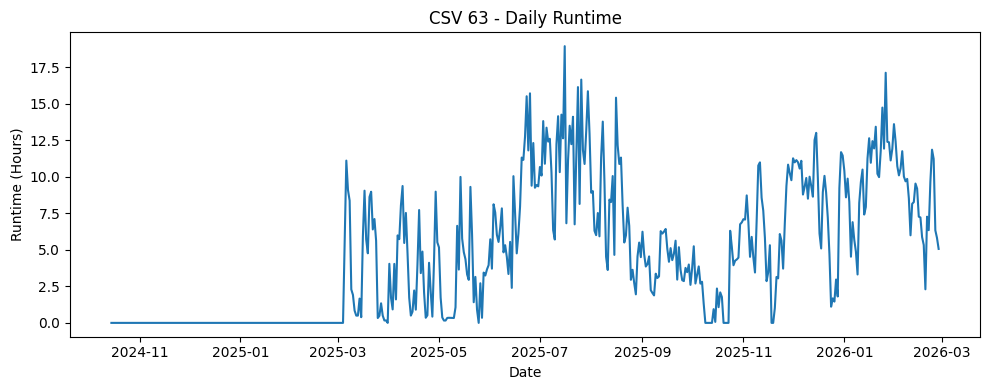

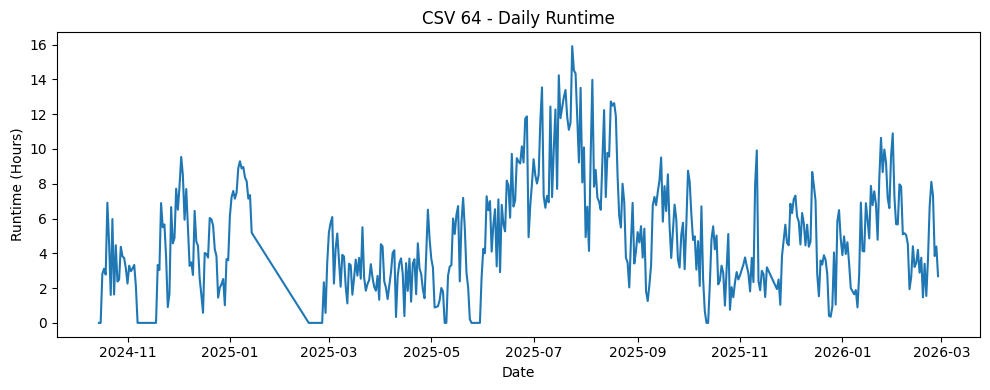

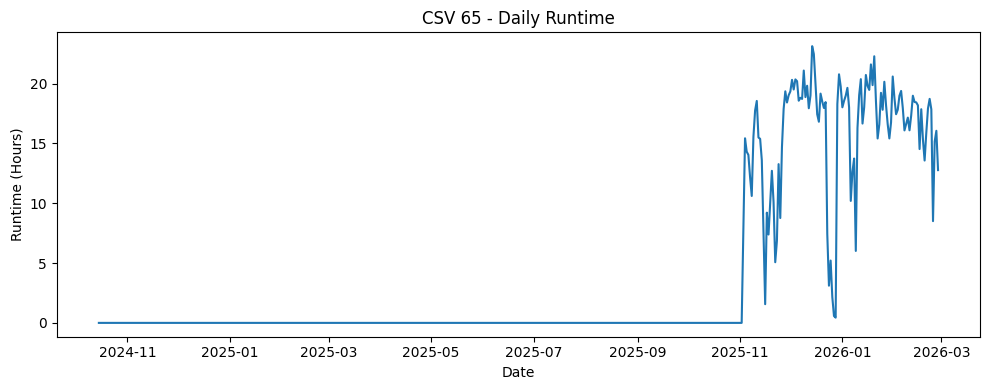

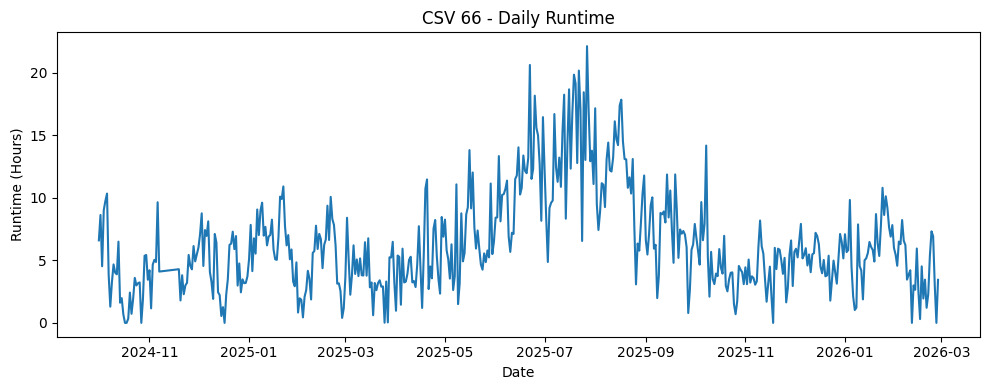

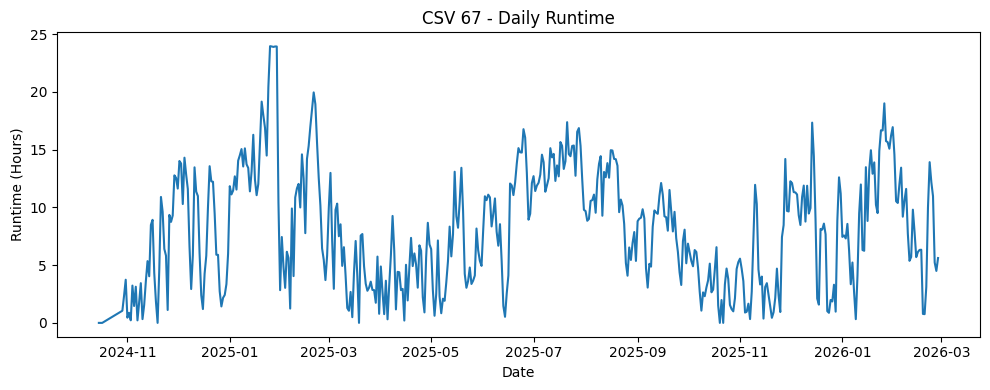

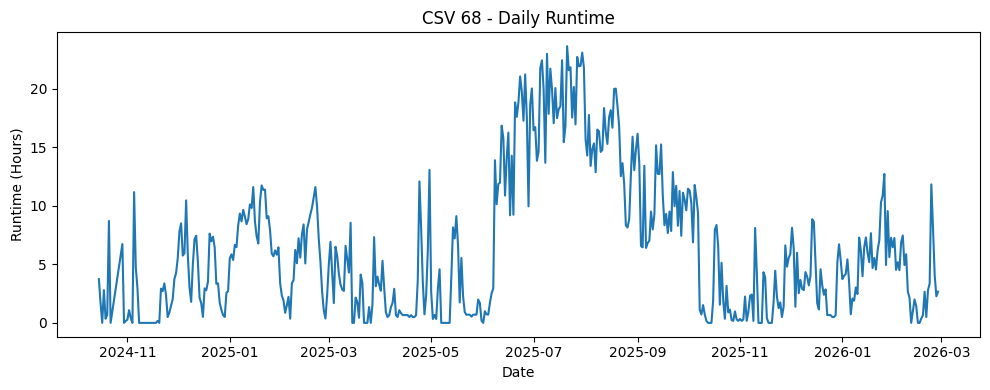

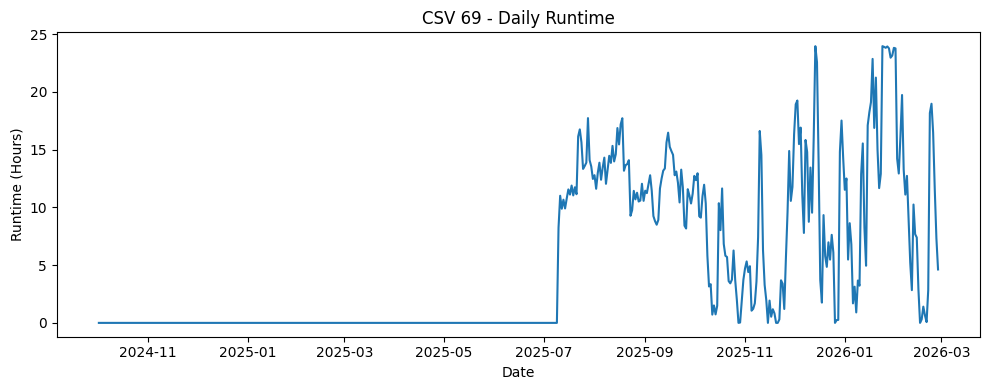

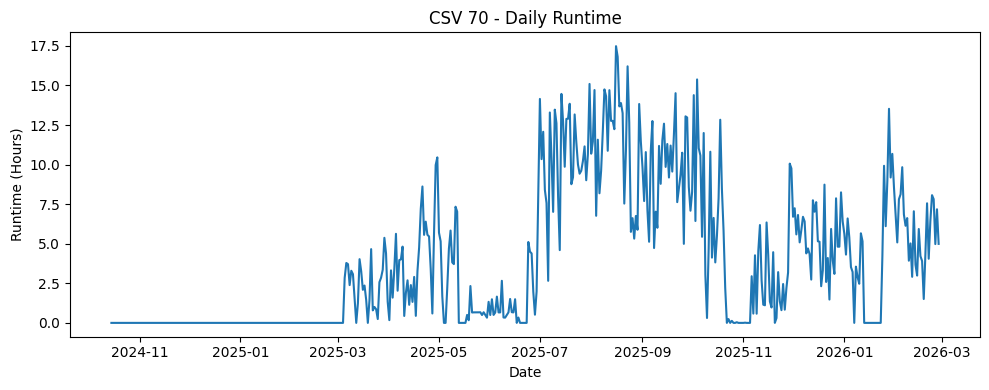

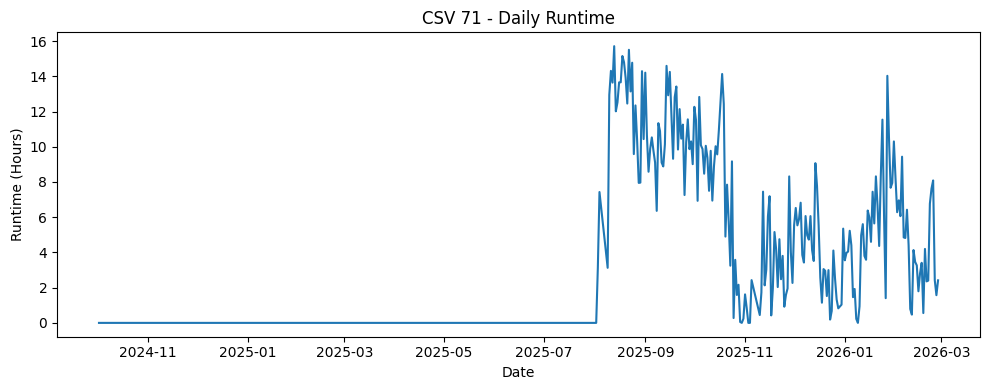

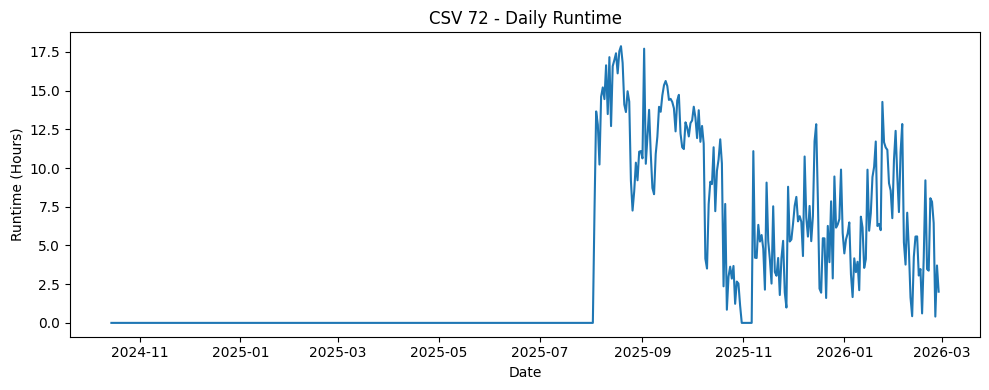

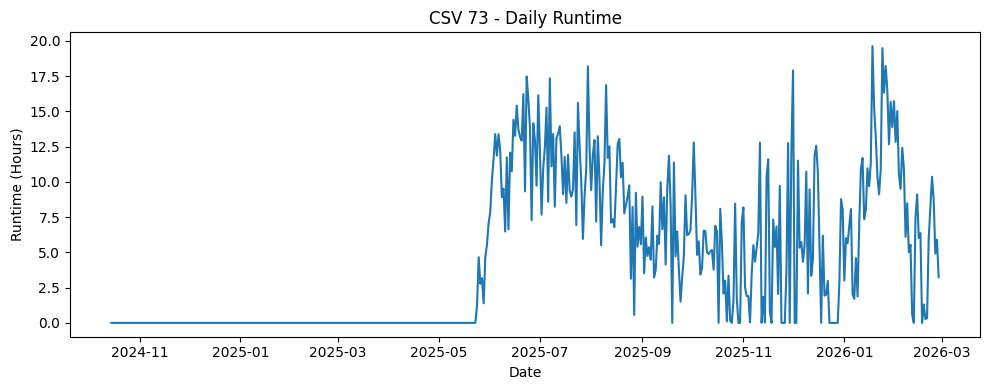

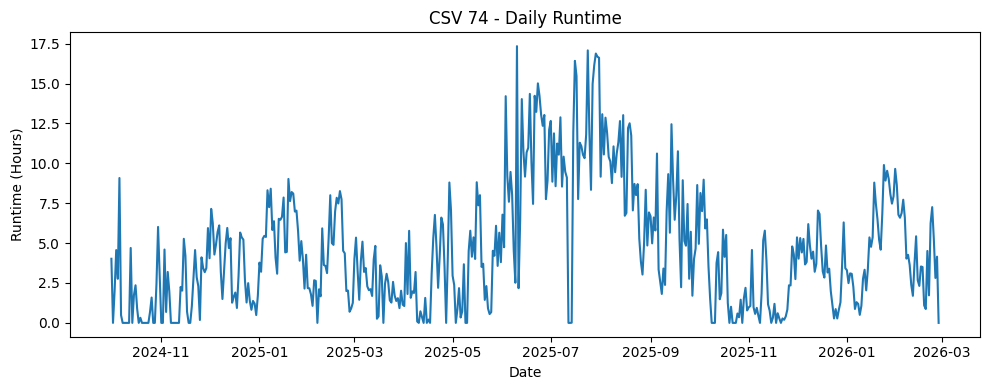

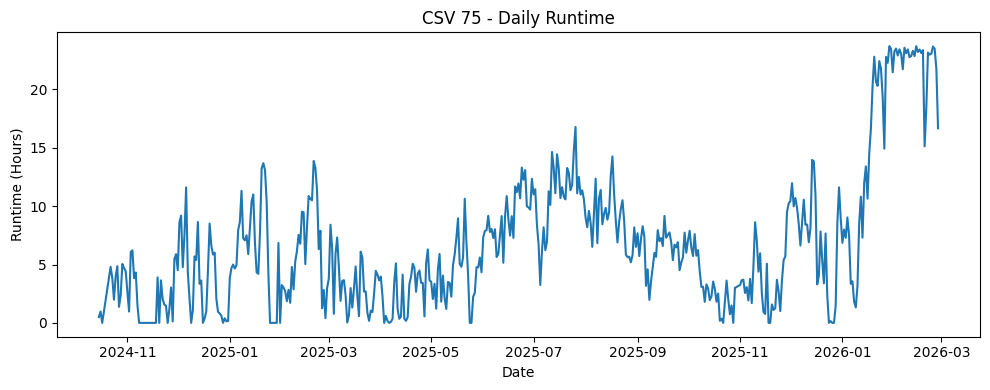

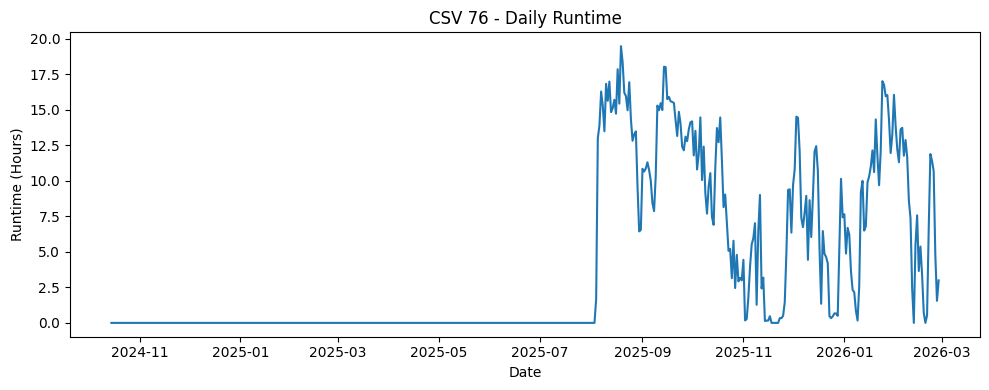

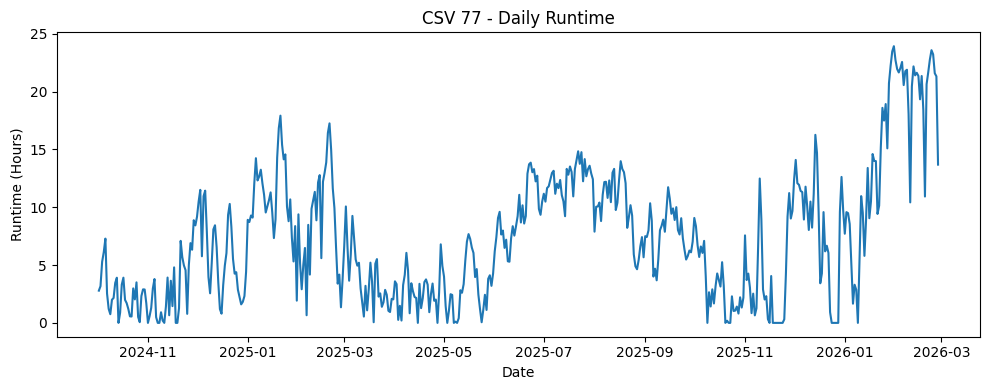

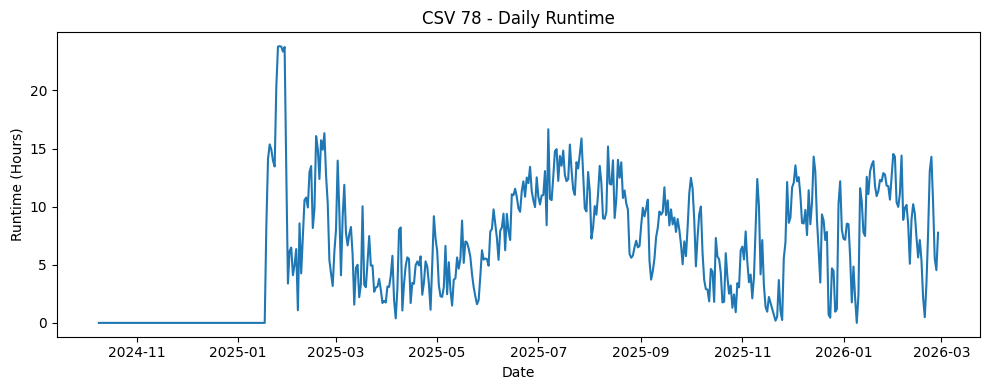

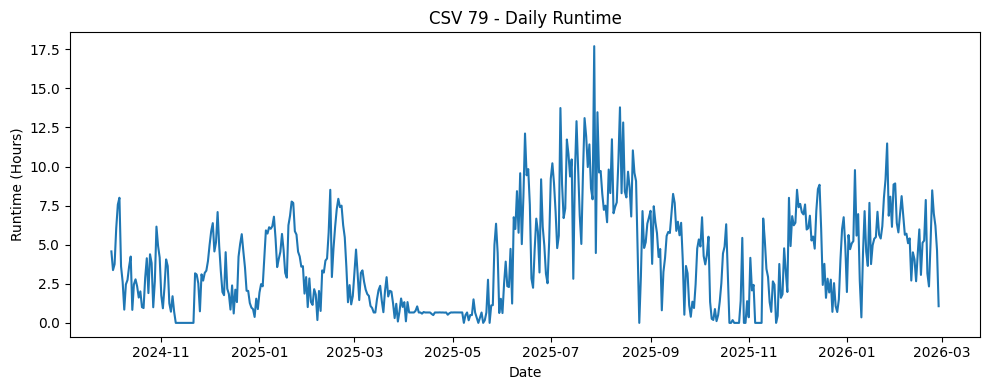

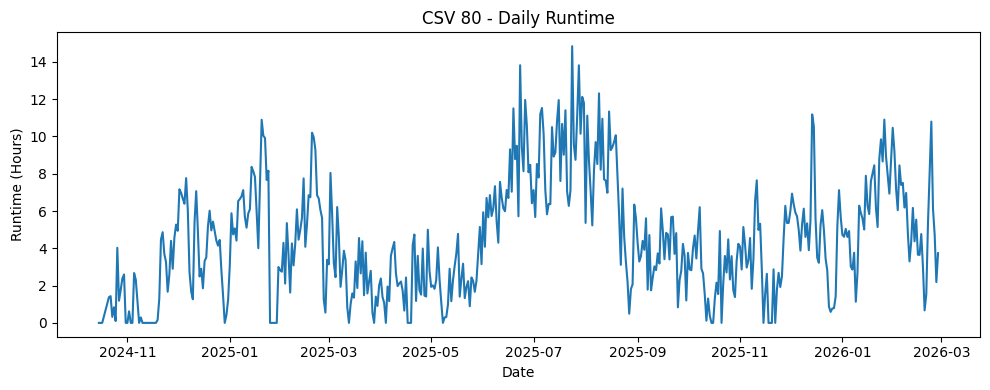

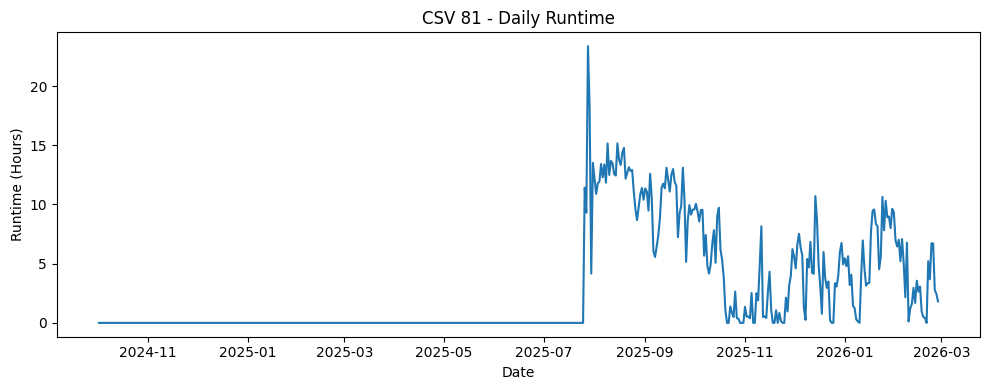

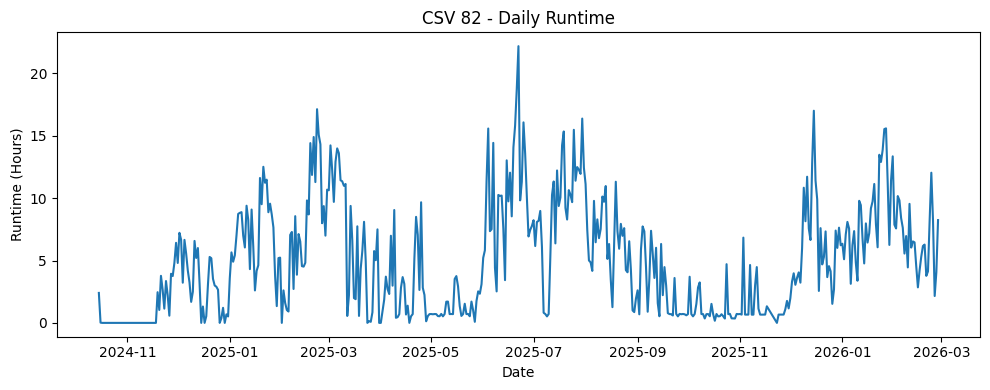

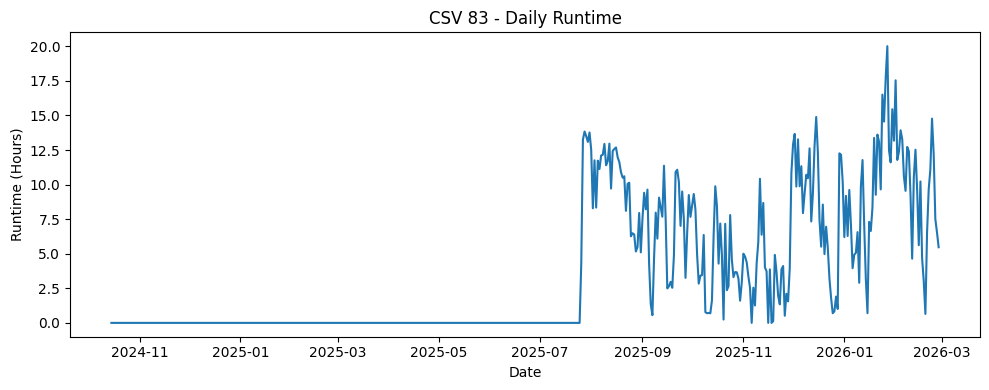

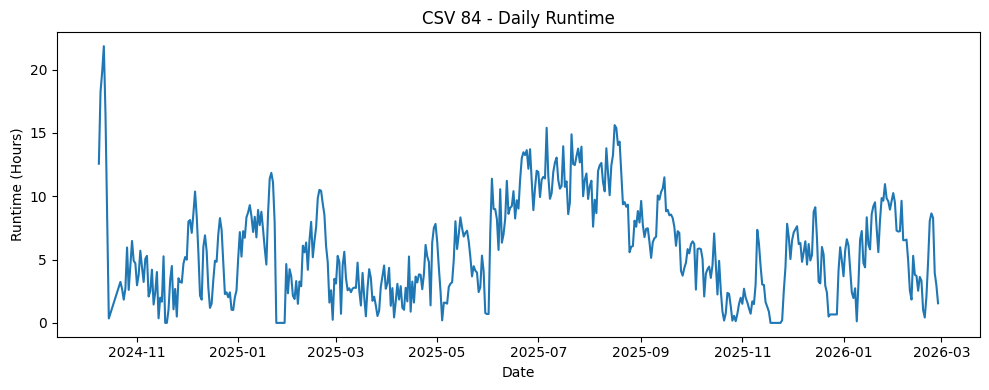

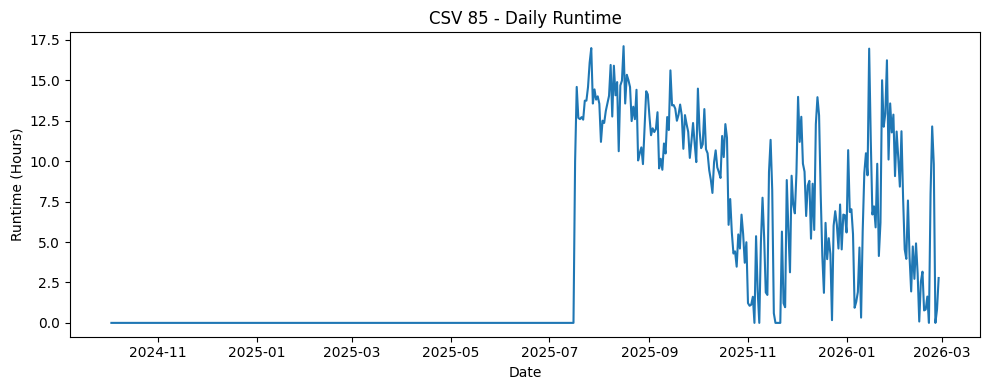

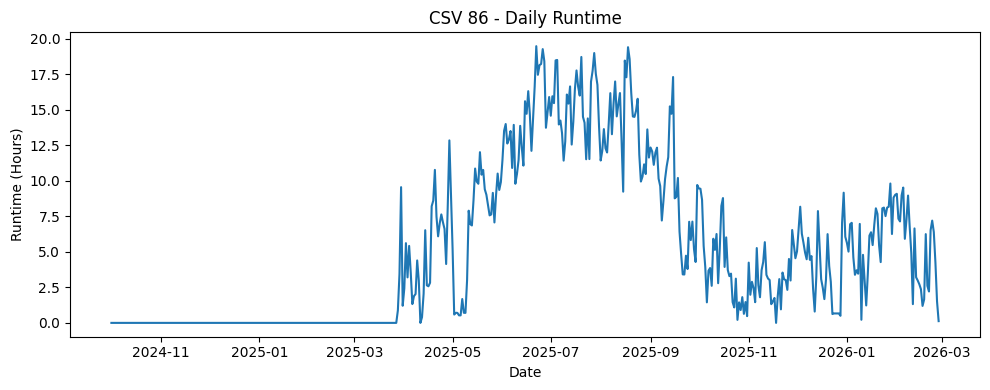

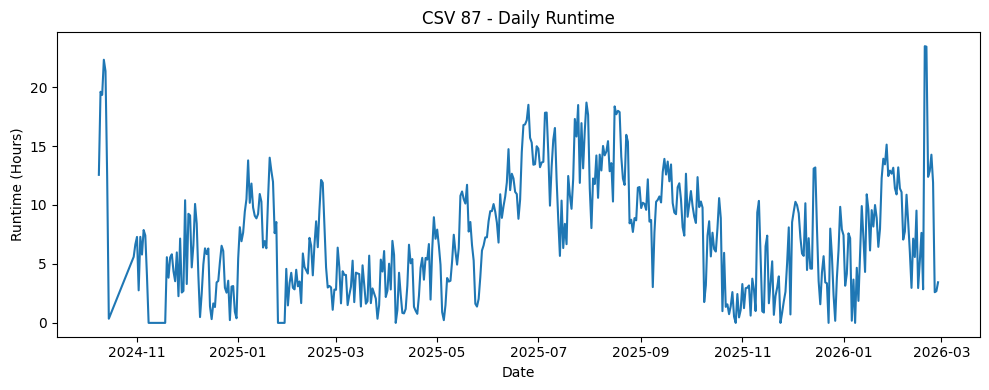

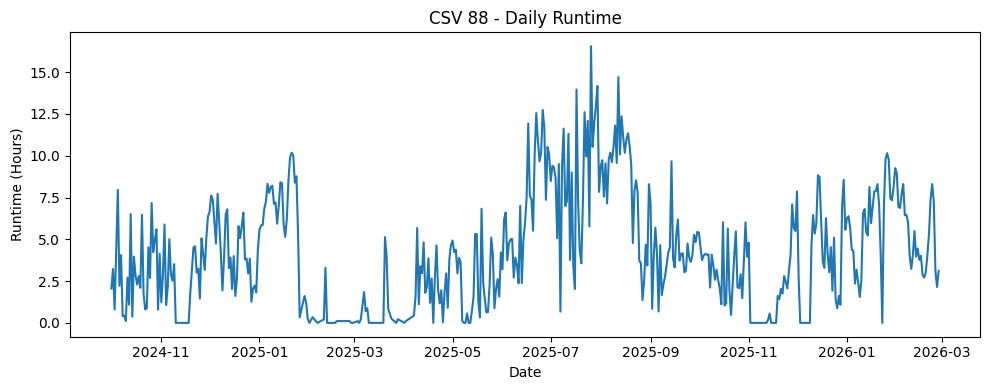

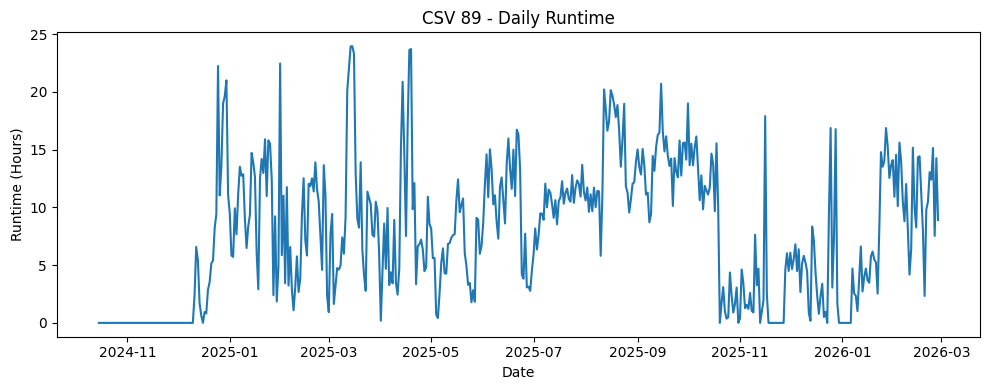

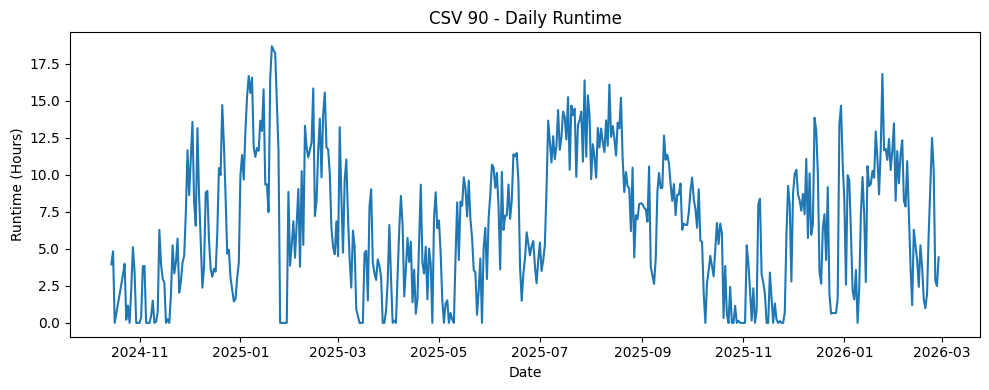

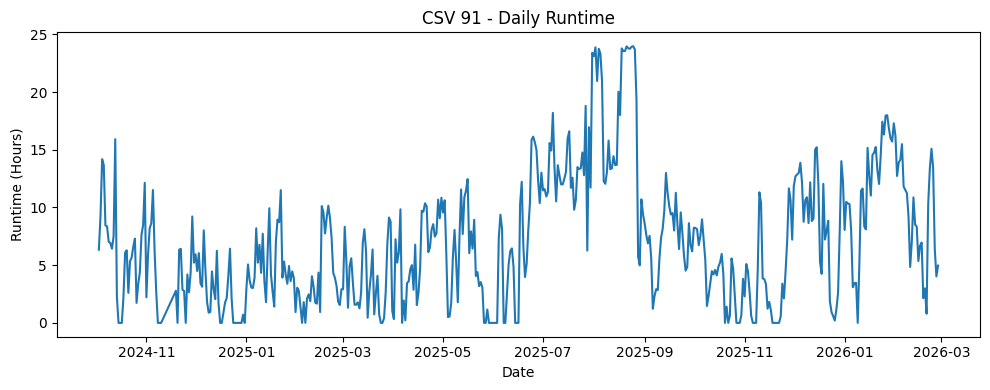

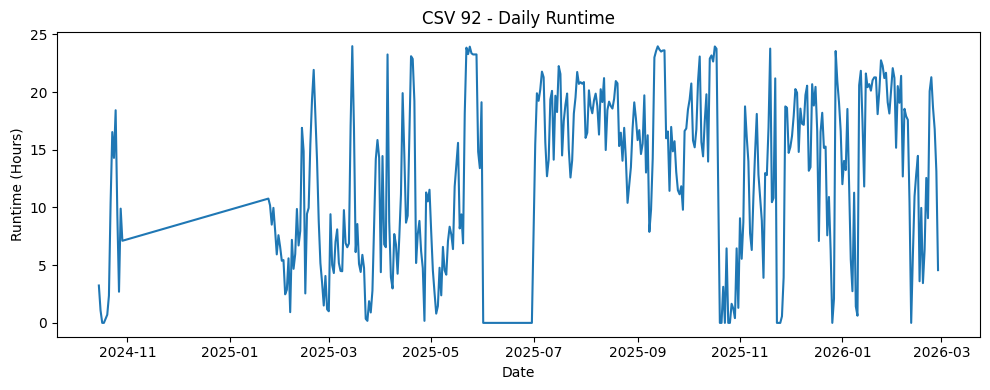

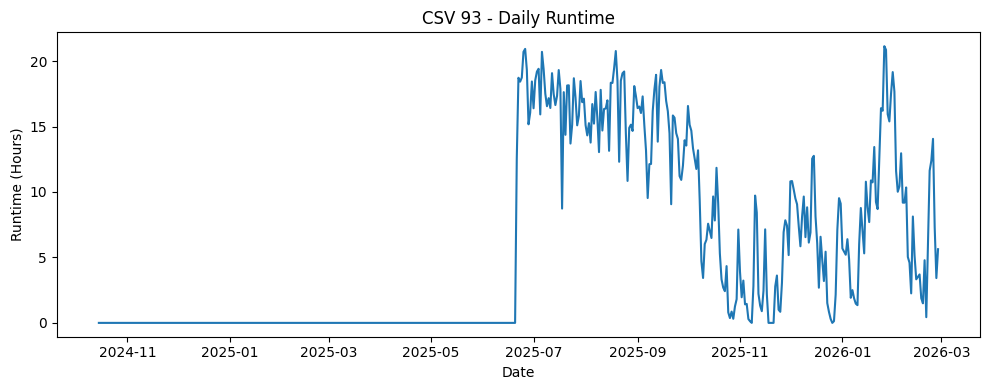

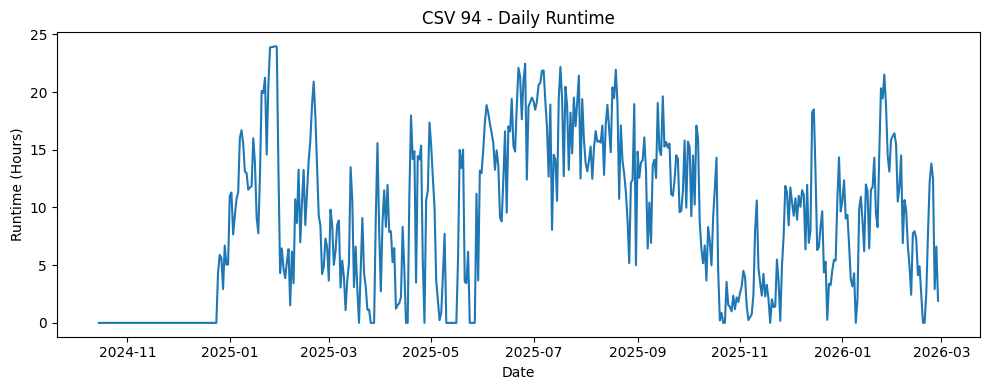

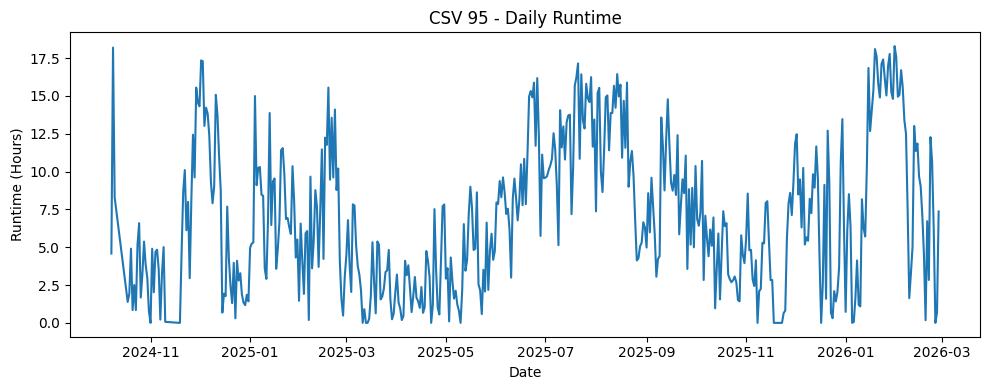

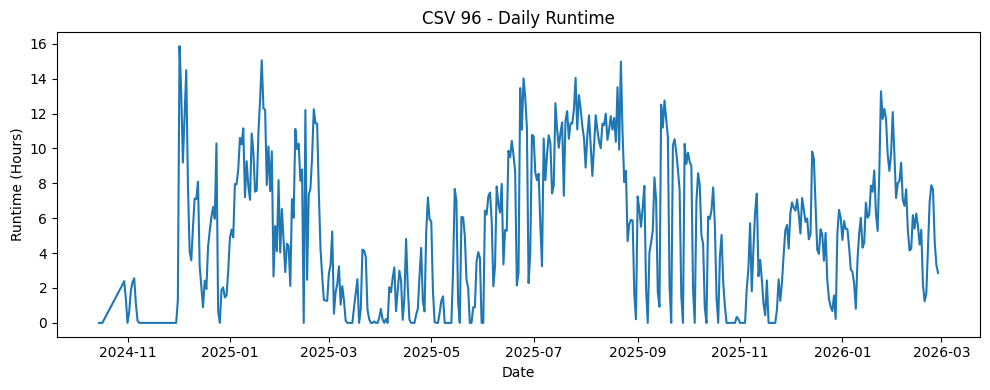

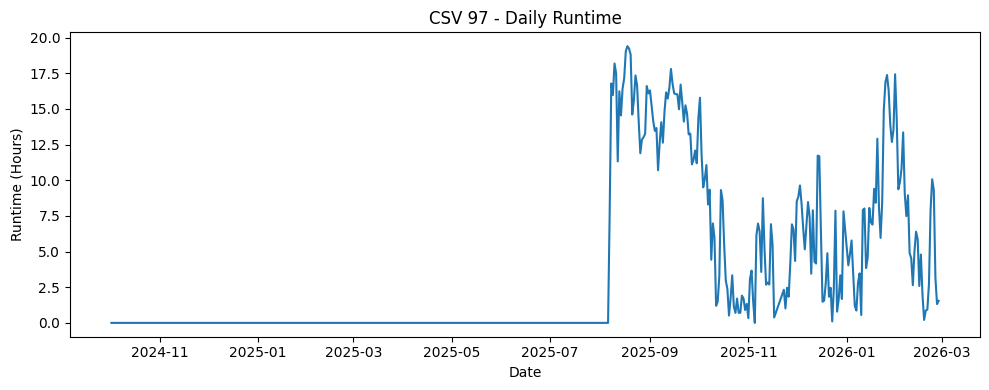

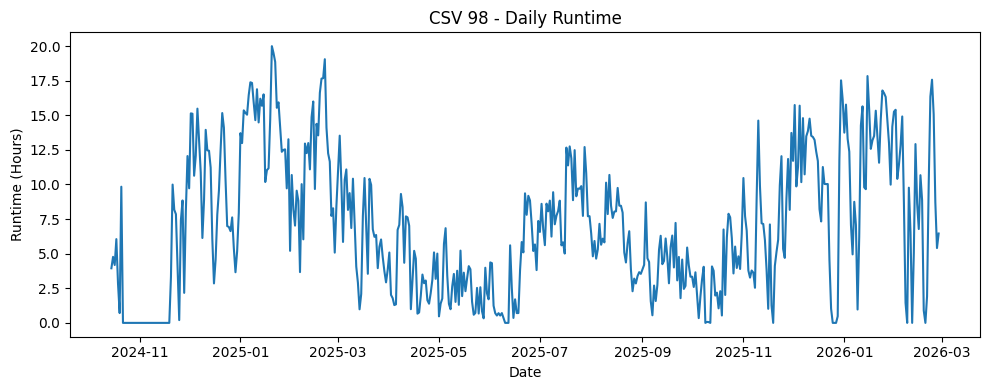

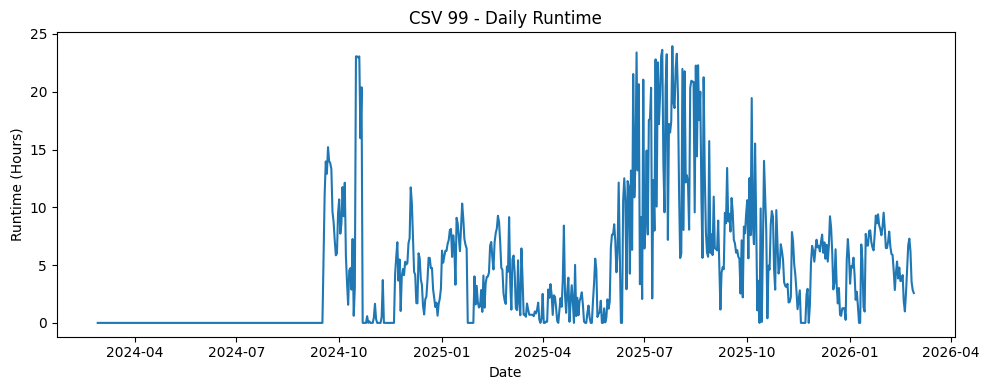

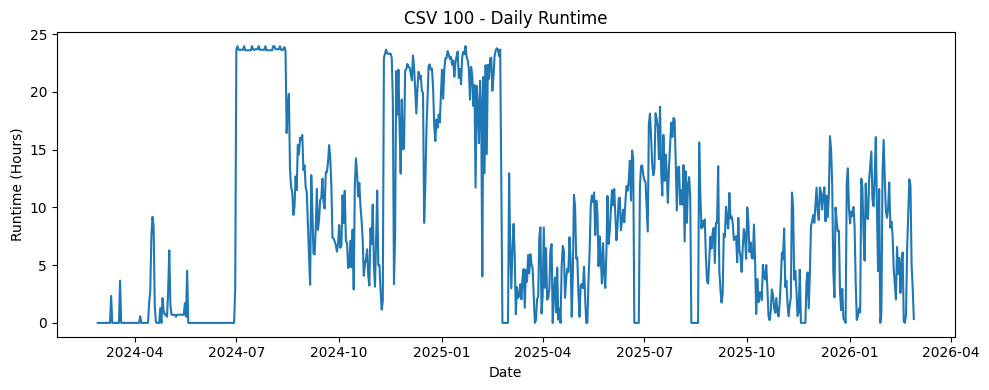

In [8]:
for i in range(1, 101):
# Set the path to the file you'd like to load
    file_path = "processed_timeseries_table_timeseries_table (" + str(i) + ").csv"
    
    # Load the latest version
    df = kagglehub.dataset_load(
      KaggleDatasetAdapter.PANDAS,
      "lsobieski/processed-thermostat-data",
      file_path,
    )
    
    df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
    df['CumulativeRuntimeHours'] = df['CumulativeRuntime'] / 3600

    df['Date'] = df['Timestamp'].dt.date

    daily_runtime = df.groupby('Date')['CumulativeRuntimeHours'].agg(['first', 'last'])
    daily_runtime['DailyRuntime'] = daily_runtime['last'] - daily_runtime['first']

    plt.figure(figsize=(10, 4))
    plt.plot(daily_runtime.index, daily_runtime['DailyRuntime'])
    
    plt.title(f'CSV {i} - Daily Runtime')
    plt.xlabel('Date')
    plt.ylabel('Runtime (Hours)')
    
    plt.tight_layout()
    plt.show()

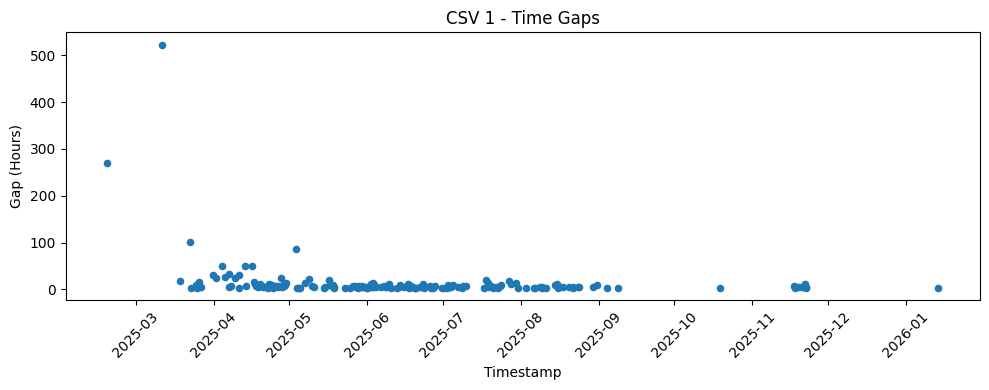

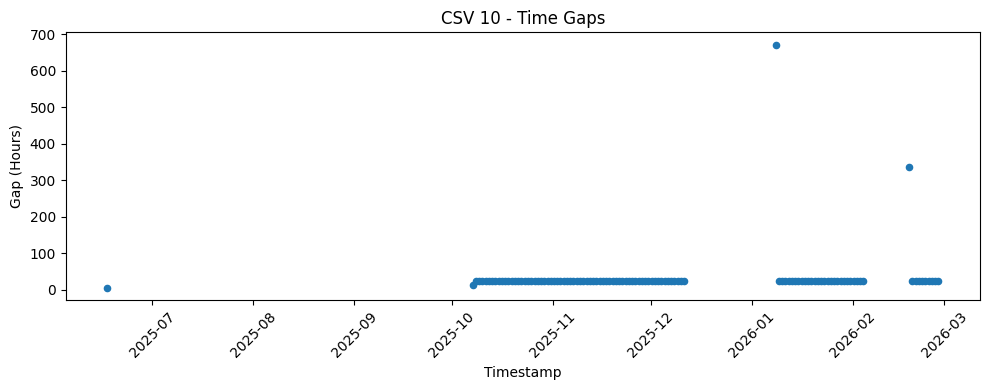

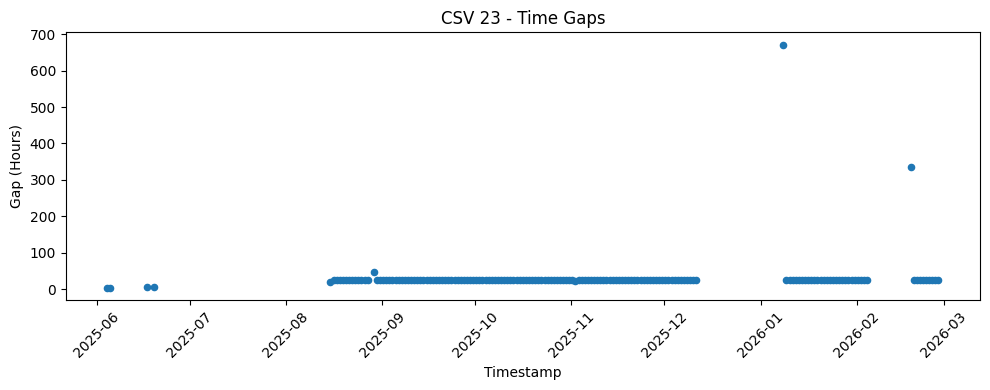

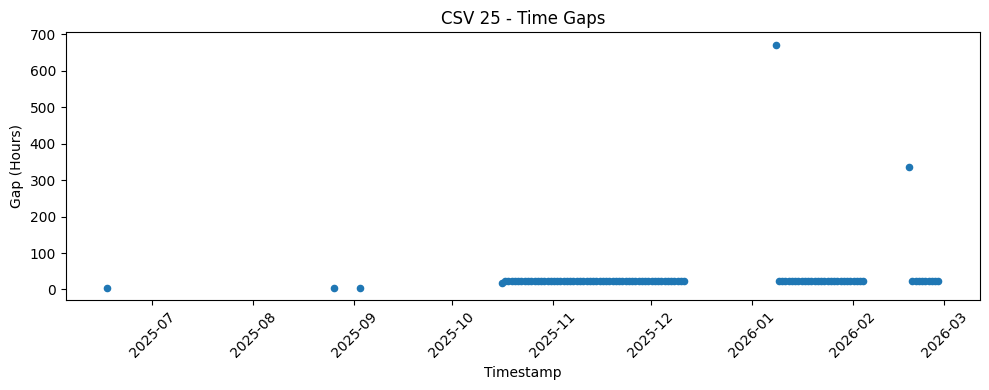

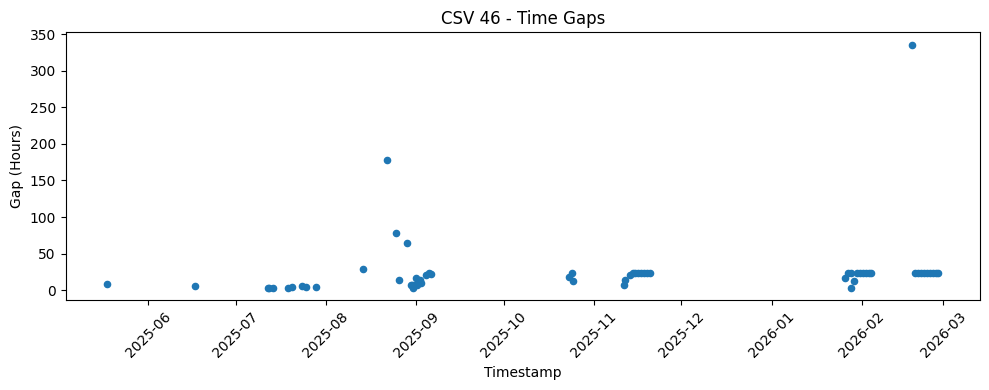

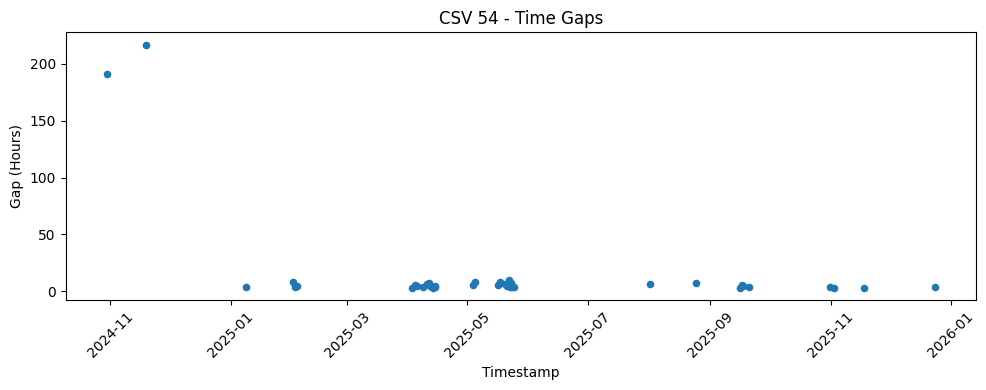

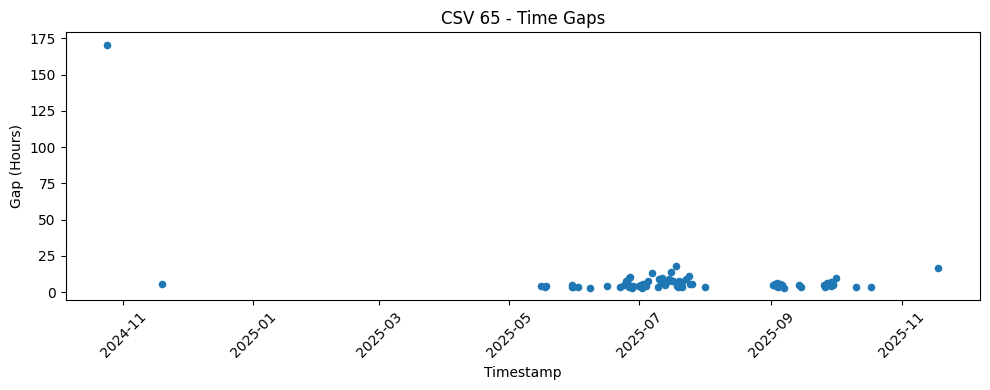

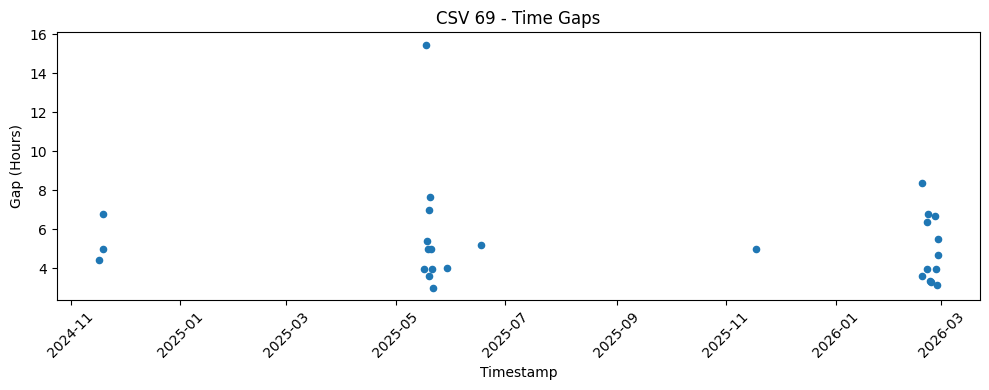

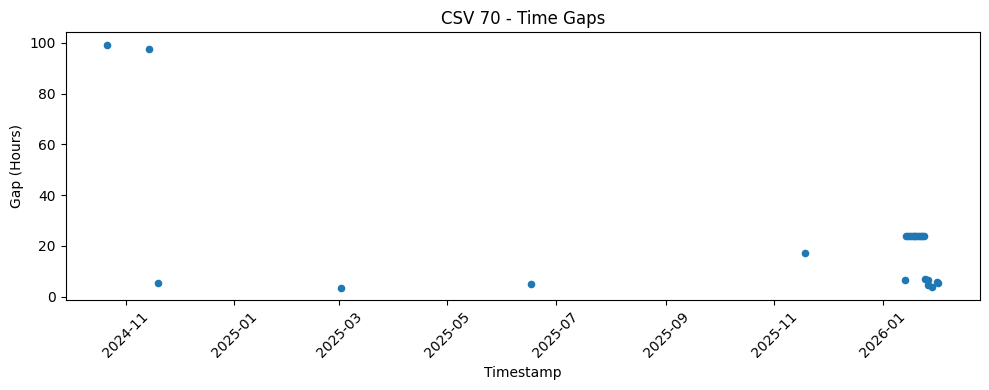

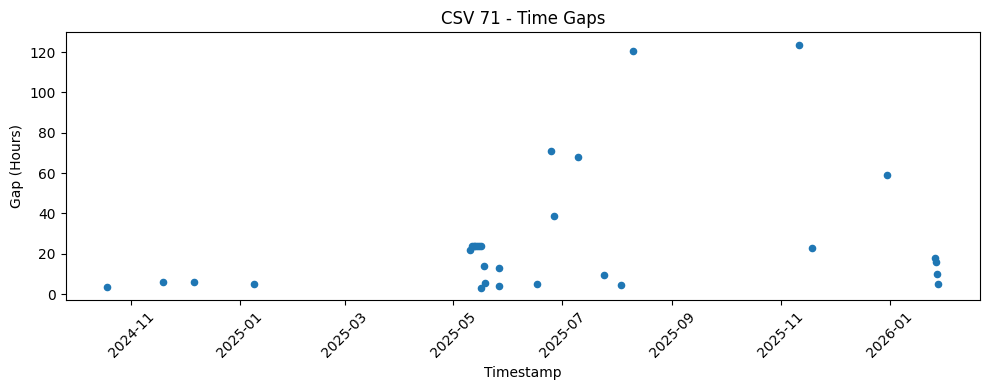

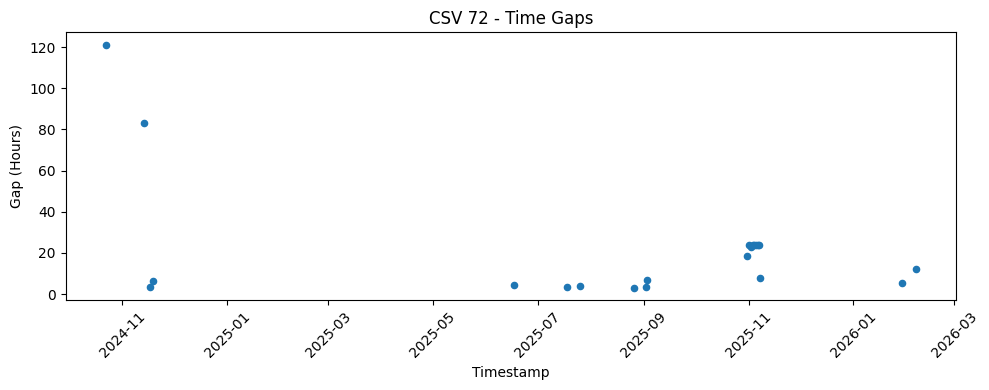

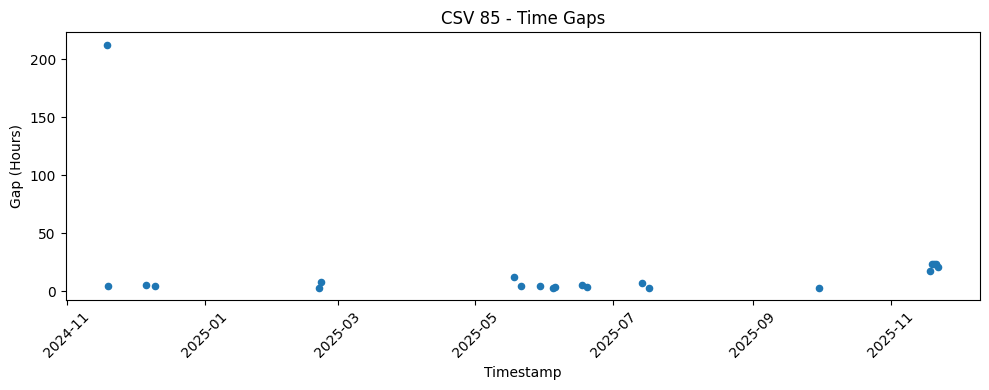

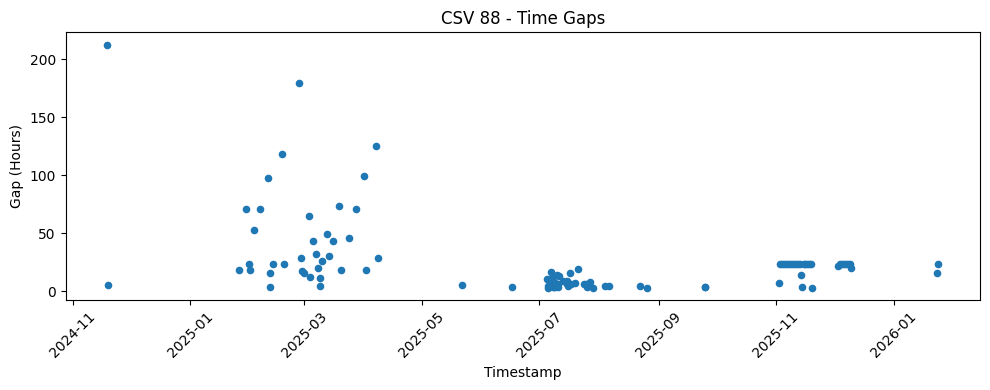

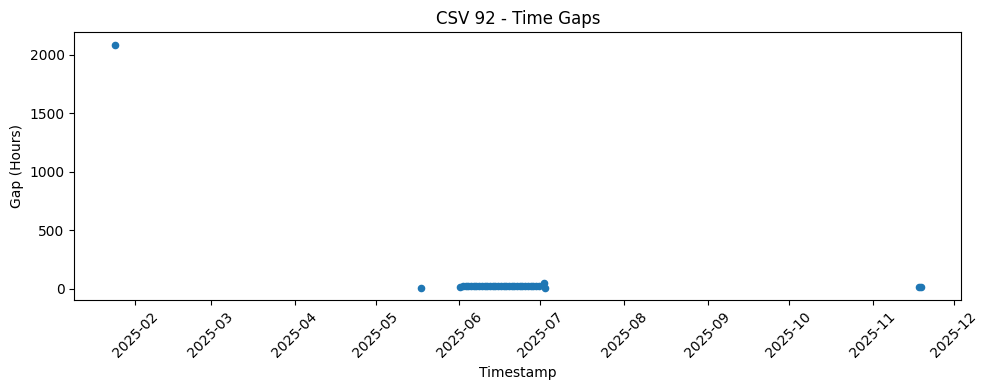

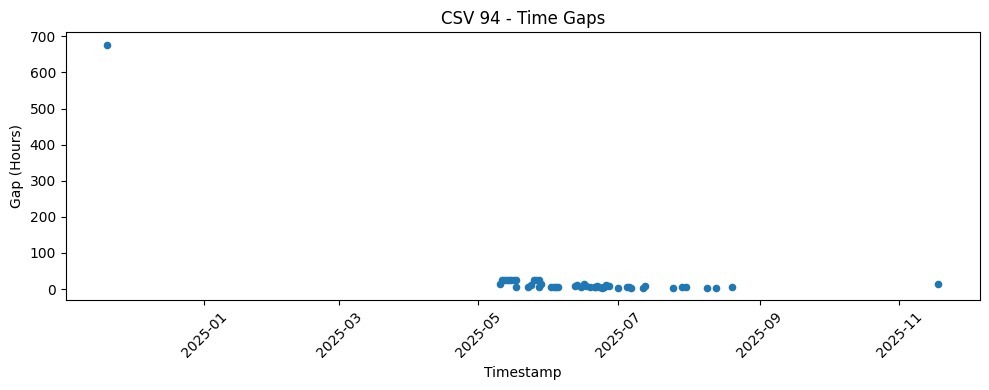

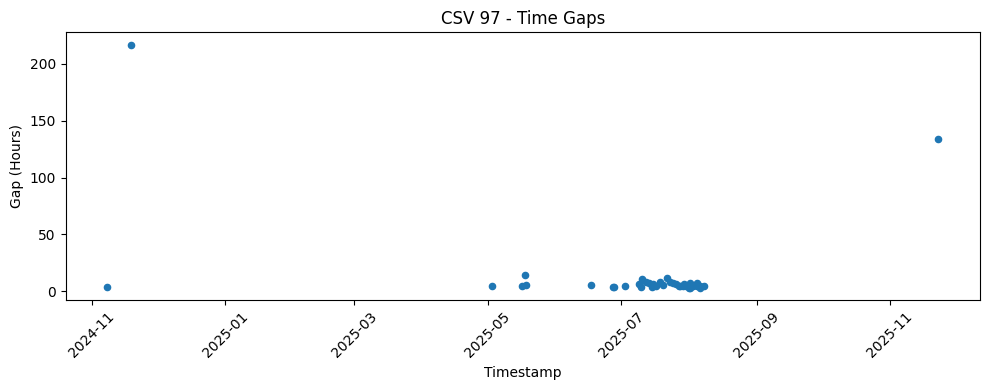

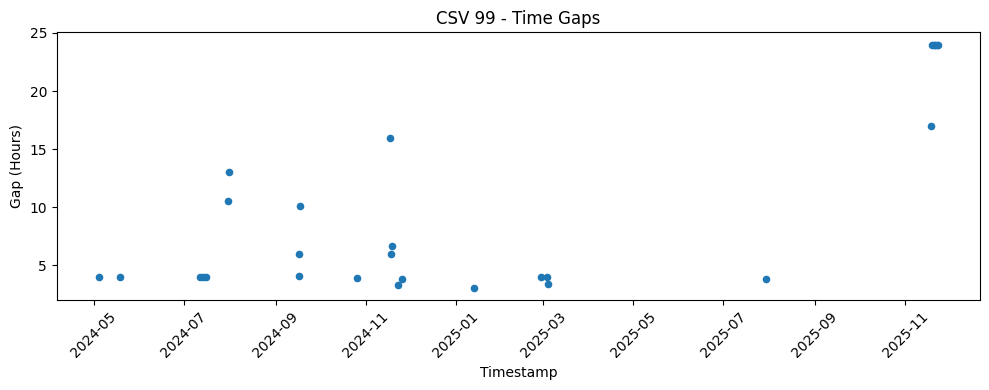

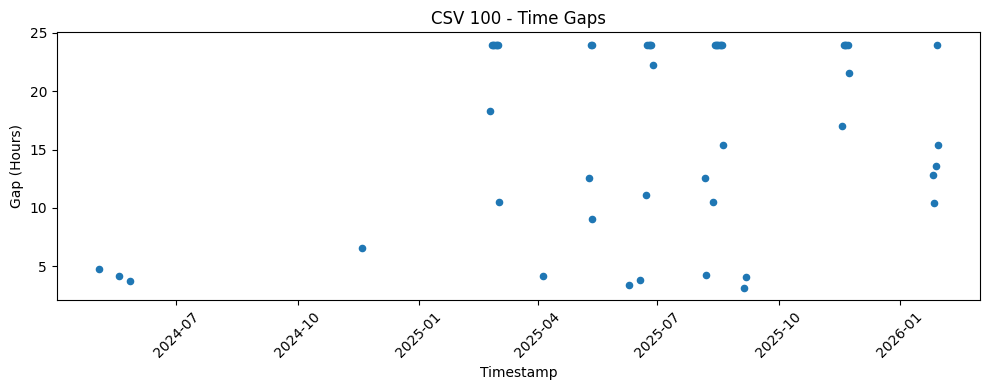

In [9]:
for i in range(1, 101):
    file_path = "processed_timeseries_table_timeseries_table (" + str(i) + ").csv"
    
    df = kagglehub.dataset_load(
        KaggleDatasetAdapter.PANDAS,
        "lsobieski/processed-thermostat-data",
        file_path,
    )
    df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')

    df["timestamp_diff"] = df["Timestamp"].diff()
    df["gap_hours"] = df["timestamp_diff"].dt.total_seconds() / 3600

    df["large_gap"] = df["gap_hours"] > 3
    gaps = df[df["large_gap"]].copy()

    if len(gaps)<20:
        continue

    plt.figure(figsize=(10, 4))
    plt.scatter(gaps['Timestamp'], gaps['gap_hours'], s=20)

    plt.title(f'CSV {i} - Time Gaps')
    plt.xlabel('Timestamp')
    plt.ylabel('Gap (Hours)')
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()